# Customer Review Decision Engine (Strict Version)

This notebook builds a review intelligence system for rigorous academic and business reporting:
- Reproducible random sampling from MongoDB
- Explicit data quality checks
- Leakage-safe train/validation/test workflow
- Model selection via cross-validation on train only
- Final evaluation on untouched test set
- Actionable product decisions from review intelligence

## 1) Imports and Global Config

All random seeds are fixed for reproducibility.

In [11]:
import re
import json
import random
import numpy as np
import pandas as pd

from pymongo import MongoClient
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 2) Load Data from MongoDB (Full Dataset by Default)

Strict protocol:
- Default mode uses **all documents** in the selected collection.
- Optional random sampling mode is preserved for quick pilot experiments.
- Stable schema is enforced at ingestion time.

In [12]:
MONGO_URI = "mongodb://localhost:27017/"
USE_FULL_DATA = True        # Strict mode requested by user/professor
SAMPLE_SIZE = 100000        # Used only when USE_FULL_DATA = False

# Set explicit database/collection for reproducible runs across machines.
PREFERRED_DB = "bigdata"
PREFERRED_COLLECTION = "review"

client = MongoClient(MONGO_URI)

skip_dbs = {"admin", "config", "local"}
selected_db, selected_col = None, None

if PREFERRED_DB and PREFERRED_COLLECTION:
    if PREFERRED_DB in client.list_database_names() and PREFERRED_COLLECTION in client[PREFERRED_DB].list_collection_names():
        selected_db, selected_col = PREFERRED_DB, PREFERRED_COLLECTION
    else:
        print("Preferred DB/collection not found; falling back to auto-detection.")

if selected_db is None:
    candidates = []
    for db_name in client.list_database_names():
        if db_name in skip_dbs:
            continue
        db_tmp = client[db_name]
        for col_name in db_tmp.list_collection_names():
            cnt = db_tmp[col_name].count_documents({})
            if cnt > 0:
                candidates.append((cnt, db_name, col_name))

    if not candidates:
        raise RuntimeError("No non-system MongoDB collection with data found.")

    candidates.sort(reverse=True)
    _, selected_db, selected_col = candidates[0]

collection = client[selected_db][selected_col]
doc_count = collection.count_documents({})

print(f"Using database: {selected_db}")
print(f"Using collection: {selected_col}")
print(f"Total documents: {doc_count:,}")

project_stage = {
    "$project": {
        "_id": 0,
        "Id": 1,
        "ProductId": 1,
        "UserId": 1,
        "Score": 1,
        "Summary": 1,
        "Text": 1,
        "ProductURL": 1,
        "HelpfulnessNumerator": 1,
        "HelpfulnessDenominator": 1,
        "Time": 1
    }
}

if USE_FULL_DATA:
    pipeline = [project_stage]
    run_label = "FULL"
else:
    pipeline = [
        {"$sample": {"size": min(SAMPLE_SIZE, doc_count)}},
        project_stage
    ]
    run_label = f"SAMPLE_{min(SAMPLE_SIZE, doc_count)}"

rows = list(collection.aggregate(pipeline, allowDiskUse=True))
df = pd.DataFrame(rows)
print(f"Run mode: {run_label}")
print("Loaded rows:", len(df))
df.head(3)

Using database: bigdata
Using collection: review
Total documents: 568,454
Run mode: FULL
Loaded rows: 568454


,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


## 3) Data Cleaning and Labeling

Rules:
- Drop exact duplicate (`ProductId`, `Text`)
- Keep non-empty text
- Build sentiment labels from rating
  - `Score > 3` => positive
  - `Score < 3` => negative
  - `Score == 3` => neutral

In [13]:
required_cols = [
    "Id", "ProductId", "UserId", "Score", "Summary", "Text", "ProductURL",
    "HelpfulnessNumerator", "HelpfulnessDenominator", "Time"
]
for col in required_cols:
    if col not in df.columns:
        df[col] = np.nan

# Normalize text/string fields
for col in ["Summary", "Text", "ProductURL", "ProductId", "UserId"]:
    df[col] = df[col].fillna("").astype(str)

# Normalize numeric fields
for col in ["Score", "HelpfulnessNumerator", "HelpfulnessDenominator", "Time"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing helpfulness with 0 and clip invalid values
for col in ["HelpfulnessNumerator", "HelpfulnessDenominator"]:
    df[col] = df[col].fillna(0)
    df[col] = df[col].clip(lower=0)

# Ensure numerator <= denominator when denominator > 0
mask_invalid_help = (df["HelpfulnessDenominator"] > 0) & (df["HelpfulnessNumerator"] > df["HelpfulnessDenominator"])
df.loc[mask_invalid_help, "HelpfulnessNumerator"] = df.loc[mask_invalid_help, "HelpfulnessDenominator"]

# Remove bad rows
df = df.dropna(subset=["Score"]).copy()
df = df[df["Text"].str.strip() != ""].copy()
before = len(df)
df = df.drop_duplicates(subset=["ProductId", "Text"], keep="first").copy()
after = len(df)
print(f"Rows after dedup: {after:,} (removed {before-after:,})")

def score_to_sentiment(s):
    if s > 3:
        return "positive"
    if s < 3:
        return "negative"
    return "neutral"

df["sentiment"] = df["Score"].apply(score_to_sentiment)
print(df["sentiment"].value_counts(normalize=True).rename("ratio"))
df.head(3)

Rows after dedup: 567,130 (removed 1,324)
sentiment
positive    0.780876
negative    0.144083
neutral     0.075041
Name: ratio, dtype: float64


,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,ProductURL,sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,,positive


## 4) Text Preprocessing (Strict and Explainable)

Preprocessing goals:
- Remove noisy artifacts (URL, HTML, punctuation)
- Normalize contractions and repeated whitespace
- Keep sentiment-critical words (e.g., negations such as `not`)
- Produce a clean, reproducible text feature input for TF-IDF

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

CONTRACTIONS = {
    "can't": "can not", "won't": "will not", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am"
}


def expand_contractions(text: str) -> str:
    out = text
    for k, v in CONTRACTIONS.items():
        out = out.replace(k, v)
    return out


def clean_text(text: str) -> str:
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\b[a-z]\b", " ", text)  # remove isolated 1-char tokens
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Keep an untouched copy for auditability
ndf = df.copy()
ndf["text_clean"] = ndf["Text"].map(clean_text)

# Remove non-product, low-information words while preserving negation words.
keep_words = {"no", "not", "never", "nor"}
domain_stopwords = {
    "them", "it", "its", "itself", "when", "will", "than", "out", "get", "other",
    "about", "only", "use", "time", "find", "little", "tried", "ive", "im", "dont",
    "would", "could", "one", "also", "really", "much", "many"
}
stopwords_final = (set(ENGLISH_STOP_WORDS) | domain_stopwords) - keep_words


def remove_non_product_words(text: str) -> str:
    tokens = re.findall(r"[a-z']+", text)
    tokens = [t for t in tokens if t not in stopwords_final and len(t) > 1]
    return " ".join(tokens)


ndf["text_clean_filtered"] = ndf["text_clean"].apply(remove_non_product_words)

# Quality filters after preprocessing
before_clean = len(ndf)
ndf = ndf[ndf["text_clean"].str.len() >= 3].copy()
ndf = ndf[ndf["text_clean_filtered"].str.len() >= 3].copy()
after_clean = len(ndf)

# Add simple quality indicators for reporting
ndf["raw_len"] = ndf["Text"].str.len()
ndf["clean_len"] = ndf["text_clean"].str.len()
ndf["filtered_len"] = ndf["text_clean_filtered"].str.len()
ndf["len_ratio"] = ndf["clean_len"] / ndf["raw_len"].replace(0, np.nan)

print(f"Rows after text cleaning: {after_clean:,} (removed {before_clean-after_clean:,})")
print(ndf[["raw_len", "clean_len", "filtered_len", "len_ratio"]].describe().T)

# Replace working dataframe
df = ndf

Rows after text cleaning: 567,109 (removed 21)
              count        mean         std        min         25%        50%  \
raw_len    567109.0  433.916092  437.625875  12.000000  179.000000  301.00000   
clean_len  567109.0  400.477210  397.409733   3.000000  167.000000  280.00000   
len_ratio  567109.0    0.929834    0.050258   0.016393    0.919048    0.93865   

                  75%           max  
raw_len    526.000000  21409.000000  
clean_len  487.000000  20212.000000  
len_ratio    0.954248      1.051471  


## 5) Preprocessing Quality Audit

This section verifies that preprocessing is valid and report-ready:
- Class distribution after cleaning
- Missing-value status of critical fields
- Examples of raw vs cleaned text

In [15]:
critical_cols = [
    "Score", "Text", "text_clean", "text_clean_filtered", "sentiment", "ProductId",
    "HelpfulnessNumerator", "HelpfulnessDenominator", "Time"
]
print("Missing values in critical columns:")
print(df[critical_cols].isna().sum())

print("\nClass distribution after preprocessing:")
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True).round(4))

print("\nRaw vs Clean/Filtered text samples:")
display(df[["Text", "text_clean", "text_clean_filtered", "sentiment"]].sample(5, random_state=SEED))

Missing values in critical columns:
Score                     0
Text                      0
text_clean                0
sentiment                 0
ProductId                 0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Time                      0
dtype: int64

Class distribution after preprocessing:
sentiment
positive    442837
negative     81714
neutral      42558
Name: count, dtype: int64
sentiment
positive    0.7809
negative    0.1441
neutral     0.0750
Name: proportion, dtype: float64

Raw vs Clean text samples:


,Text,text_clean,sentiment
438955,I first tasted this coffee at the Hyatt at Phi...,first tasted this coffee at the hyatt at phila...,positive
246139,Many people have referred to the fact that thi...,many people have referred to the fact that thi...,neutral
282388,I usually feed my dogs soft and chewy treats b...,usually feed my dogs soft and chewy treats but...,positive
26782,This tea is incredible!! The complexity of the...,this tea is incredible the complexity of the f...,positive
209016,"very hard to set, you could loose fingers if y...",very hard to set you could loose fingers if yo...,negative


## 6) Strict Split: Train / Validation / Test

Model selection uses train+validation only.
Final test is untouched until the very end.

In [16]:
# Use filtered text for model training
X = df["text_clean_filtered"]
y = df["sentiment"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=SEED, stratify=y_trainval
)
# 0.85 * 0.1765 ~= 0.15 => approx 70/15/15

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 396961 Val: 85081 Test: 85067


## 7) Model Training with CV (No Test Leakage)

We run three strong baselines:
- MultinomialNB
- Logistic Regression
- LinearSVC

Vectorizer is inside pipeline, so each CV fold is leakage-safe.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

experiments = {
    "nb": {
        "pipe": Pipeline([
            ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
            ("clf", MultinomialNB())
        ]),
        "params": {"clf__alpha": [0.1, 0.5, 1.0]}
    },
    "lr": {
        "pipe": Pipeline([
            ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
        ]),
        "params": {"clf__C": [0.1, 1, 3]}
    },
    "svm": {
        "pipe": Pipeline([
            ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
            ("clf", LinearSVC(class_weight="balanced", random_state=SEED))
        ]),
        "params": {"clf__C": [0.1, 1, 3]}
    }
}

best_models = {}
for name, spec in experiments.items():
    gs = GridSearchCV(
        estimator=spec["pipe"],
        param_grid=spec["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)
    best_models[name] = gs
    print(f"[{name}] best params: {gs.best_params_}, cv f1_macro: {gs.best_score_:.4f}")

[nb] best params: {'clf__alpha': 0.1}, cv f1_macro: 0.5864
[lr] best params: {'clf__C': 3}, cv f1_macro: 0.7236
[svm] best params: {'clf__C': 1}, cv f1_macro: 0.7489


## 8) Validation Comparison and Final Test

Select best model by validation macro-F1, then evaluate once on test.

In [18]:
def evaluate_model(model, X_eval, y_eval, name="model"):
    pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_eval, pred, average="macro", zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_eval, pred, average="weighted", zero_division=0)
    return {
        "model": name,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "pred": pred
    }

val_rows = []
for name, gs in best_models.items():
    out = evaluate_model(gs.best_estimator_, X_val, y_val, name)
    val_rows.append({k: v for k, v in out.items() if k != "pred"})

val_df = pd.DataFrame(val_rows).sort_values("f1_macro", ascending=False)
display(val_df)

winner = val_df.iloc[0]["model"]
best_estimator = best_models[winner].best_estimator_
print("Selected model:", winner)

# Refit winner on train+val, then evaluate test once
best_estimator.fit(X_trainval, y_trainval)
test_pred = best_estimator.predict(X_test)

print("\n=== FINAL TEST REPORT ===")
print(classification_report(y_test, test_pred, digits=4))
print("Confusion Matrix (labels: negative, neutral, positive):")
print(confusion_matrix(y_test, test_pred, labels=["negative", "neutral", "positive"]))

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
2,svm,0.889317,0.737075,0.774178,0.753871,0.893174
1,lr,0.853880,0.695187,0.796408,0.727393,0.869347
0,nb,0.855444,0.744136,0.547406,0.586149,0.827268


Selected model: svm

=== FINAL TEST REPORT ===
              precision    recall  f1-score   support

    negative     0.7729    0.8168    0.7943     12257
     neutral     0.4841    0.5735    0.5250      6384
    positive     0.9630    0.9358    0.9492     66426

    accuracy                         0.8915     85067
   macro avg     0.7400    0.7754    0.7562     85067
weighted avg     0.8997    0.8915    0.8951     85067

Confusion Matrix (labels: negative, neutral, positive):
[[10012  1298   947]
 [ 1281  3661  1442]
 [ 1660  2603 62163]]


## 9) Business Signals from Reviews (Actionable Output)

Simple rule-based aspect flags for operational decisions.

In [19]:
aspect_keywords = {
    "delivery": ["delivery", "ship", "shipping", "arrive", "late"],
    "packaging_damage": ["broken", "damaged", "leak", "crushed", "package"],
    "price_value": ["price", "expensive", "cheap", "value", "worth"],
    "product_quality": ["quality", "taste", "flavor", "fresh", "defect"]
}

NEGATION_TOKENS = ("not", "no", "never", "without")


def keyword_hit_with_negation_guard(text, keyword):
    kw = re.escape(keyword)
    positive_pat = rf"\b{kw}\b"
    negated_pat = rf"\b(?:{'|'.join(NEGATION_TOKENS)})\s+{kw}\b"
    return bool(re.search(positive_pat, text)) and not bool(re.search(negated_pat, text))


def flag_aspects(text):
    hit = {}
    for asp, kws in aspect_keywords.items():
        hit[asp] = int(any(keyword_hit_with_negation_guard(text, kw) for kw in kws))
    return pd.Series(hit)


aspect_df = df[["ProductId", "sentiment", "text_clean"]].copy()
aspect_flags = aspect_df["text_clean"].apply(flag_aspects)
aspect_df = pd.concat([aspect_df, aspect_flags], axis=1)

neg = aspect_df[aspect_df["sentiment"] == "negative"]
summary = {
    k: float(neg[k].mean()) if len(neg) else 0.0
    for k in aspect_keywords
}
print("Negative-review aspect incidence:")
print(pd.Series(summary).sort_values(ascending=False))

Negative-review aspect incidence:
product_quality     0.389982
price_value         0.144626
packaging_damage    0.081871
delivery            0.057126
dtype: float64


## 10) Export Artifacts for Reporting (Safe Export)

These files are required for reporting evidence.
If a target CSV is locked/opened by another app, fallback filenames are used automatically.

In [20]:
def safe_to_csv(df_obj, primary_name):
    try:
        df_obj.to_csv(primary_name, index=False)
        print(f"Saved: {primary_name}")
    except PermissionError:
        fallback = primary_name.replace('.csv', '_new.csv')
        df_obj.to_csv(fallback, index=False)
        print(f"PermissionError on {primary_name}; saved fallback: {fallback}")

safe_to_csv(val_df, "strict_model_validation_results.csv")
safe_to_csv(pd.DataFrame({"y_true": y_test.values, "y_pred": test_pred}), "strict_test_predictions.csv")
safe_to_csv(df[["Id", "ProductId", "Score", "sentiment", "text_clean"]], "strict_cleaned_full.csv")

print("Export step completed.")

Saved: strict_model_validation_results.csv
Saved: strict_test_predictions.csv
Saved: strict_cleaned_full.csv
Export step completed.


## 11) Credibility Scoring with Helpfulness (Wilson Lower Bound)

Why this matters for business:
- Reviews with few votes are noisy.
- We assign each review a credibility score using Wilson lower bound.
- Product-level decisions then prioritize signals with stronger evidence.

In [21]:
# Wilson lower bound for Bernoulli proportion p = helpful_num / helpful_den
# z=1.96 => 95% confidence

def wilson_lower_bound(pos, n, z=1.96):
    if n <= 0:
        return 0.0
    phat = pos / n
    denominator = 1 + z**2 / n
    numerator = phat + z**2/(2*n) - z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n)
    return numerator / denominator


df["helpful_num"] = df["HelpfulnessNumerator"].astype(float)
df["helpful_den"] = df["HelpfulnessDenominator"].astype(float)
df["helpful_ratio"] = np.where(df["helpful_den"] > 0, df["helpful_num"] / df["helpful_den"], 0.0)

df["review_credibility"] = [
    wilson_lower_bound(p, n)
    for p, n in zip(df["helpful_num"].values, df["helpful_den"].values)
]

print(df[["helpful_num", "helpful_den", "helpful_ratio", "review_credibility"]].describe().T)

                       count      mean       std           min  25%  50%  \
helpful_num         567109.0  1.741371  7.640057  0.000000e+00  0.0  0.0   
helpful_den         567109.0  2.224371  8.289614  0.000000e+00  0.0  1.0   
helpful_ratio       567109.0  0.407787  0.462095  0.000000e+00  0.0  0.0   
review_credibility  567109.0  0.146894  0.200552 -2.209651e-17  0.0  0.0   

                         75%         max  
helpful_num         2.000000  866.000000  
helpful_den         2.000000  923.000000  
helpful_ratio       1.000000    1.000000  
review_credibility  0.206543    0.984424  


## 12) Time Trend and Early Warning Signals

We convert Unix `Time` to calendar month and monitor negative sentiment trend.
A rising short-term negative rate vs long-term baseline triggers early-warning.

In [22]:
# Time conversion (dataset has Unix timestamp in seconds)
df["review_datetime"] = pd.to_datetime(df["Time"], unit="s", errors="coerce")
df["review_month"] = df["review_datetime"].dt.to_period("M").astype(str)

# Build monthly trend table
time_df = df.dropna(subset=["review_datetime"]).copy()
time_df["is_negative"] = (time_df["sentiment"] == "negative").astype(int)

monthly = (
    time_df
    .groupby("review_month")
    .agg(
        reviews=("Id", "count"),
        neg_rate=("is_negative", "mean"),
        mean_score=("Score", "mean")
    )
    .reset_index()
    .sort_values("review_month")
)

monthly["neg_rate_3m"] = monthly["neg_rate"].rolling(3, min_periods=1).mean()
monthly["neg_rate_12m"] = monthly["neg_rate"].rolling(12, min_periods=3).mean()
monthly["early_warning"] = (monthly["neg_rate_3m"] - monthly["neg_rate_12m"]) > 0.02

print("Latest 12 months trend:")
display(monthly.tail(12))

latest_warning = bool(monthly["early_warning"].iloc[-1]) if len(monthly) else False
print("Global early-warning status:", latest_warning)

Latest 12 months trend:


,review_month,reviews,neg_rate,mean_score,neg_rate_3m,neg_rate_12m,early_warning
131,2011-11,16217,0.153604,4.133625,0.149187,0.151940,False
132,2011-12,19035,0.172367,4.080273,0.159857,0.152162,False
133,2012-01,21682,0.171525,4.095794,0.165832,0.152707,False
134,2012-02,18794,0.160902,4.105300,0.168265,0.152291,False
135,2012-03,19707,0.165068,4.071548,0.165832,0.154449,False
136,2012-04,18897,0.153781,4.126581,0.159917,0.155443,False
137,2012-05,19396,0.154413,4.119509,0.157754,0.156538,False
138,2012-06,18089,0.161092,4.085024,0.156429,0.156526,False
139,2012-07,19835,0.149836,4.147719,0.155114,0.156536,False
140,2012-08,19798,0.156935,4.124053,0.155955,0.157790,False


Global early-warning status: False


## 13) Review Intelligence Scoring and Product Decision Engine

This block generates a decision-ready product table:
- Combines sentiment, volume, credibility, and complaint patterns
- Produces recommended actions: INVEST / FIX / KILL-OR-REDESIGN / MONITOR

In [23]:
# Rebuild aspect flags with clean text for product-level scoring
# Reuse the same aspect rules defined earlier for consistency.
prod_base = df[[
    "Id", "ProductId", "Score", "sentiment", "text_clean", "review_credibility", "review_datetime"
]].copy()
prod_flags = prod_base["text_clean"].apply(flag_aspects)
prod_df = pd.concat([prod_base, prod_flags], axis=1)

# sentiment indicator columns
prod_df["is_pos"] = (prod_df["sentiment"] == "positive").astype(int)
prod_df["is_neg"] = (prod_df["sentiment"] == "negative").astype(int)
prod_df["is_neu"] = (prod_df["sentiment"] == "neutral").astype(int)

# Weighted sentiment score in [-1, 1] using review credibility
sent_map = {"negative": -1.0, "neutral": 0.0, "positive": 1.0}
prod_df["sent_score"] = prod_df["sentiment"].map(sent_map)
prod_df["weighted_sent"] = prod_df["sent_score"] * prod_df["review_credibility"]

# Aggregate by product
product_metrics = (
    prod_df
    .groupby("ProductId")
    .agg(
        review_count=("Id", "count"),
        mean_score=("Score", "mean"),
        pos_rate=("is_pos", "mean"),
        neg_rate=("is_neg", "mean"),
        neu_rate=("is_neu", "mean"),
        avg_credibility=("review_credibility", "mean"),
        weighted_sentiment=("weighted_sent", "mean"),
        delivery_rate=("delivery", "mean"),
        packaging_damage_rate=("packaging_damage", "mean"),
        price_value_rate=("price_value", "mean"),
        product_quality_rate=("product_quality", "mean"),
        last_review_date=("review_datetime", "max")
    )
    .reset_index()
)

# Risk and opportunity scores (heuristic but explicit)
# MIN_REVIEWS guard prevents over-confident actions on very small samples.
MIN_REVIEWS = 30

# Demand proxy quantiles are computed on reliable products only.
# This avoids distorted thresholds caused by long-tail products with 1-2 reviews.
reliable_products = product_metrics[product_metrics["review_count"] >= MIN_REVIEWS]
if len(reliable_products) > 0:
    q75 = reliable_products["review_count"].quantile(0.75)
    q25 = reliable_products["review_count"].quantile(0.25)
else:
    q75 = product_metrics["review_count"].quantile(0.75)
    q25 = product_metrics["review_count"].quantile(0.25)

product_metrics["demand_segment"] = np.select(
    [product_metrics["review_count"] >= q75, product_metrics["review_count"] <= q25],
    ["high", "low"],
    default="mid"
)

base_risk = (
    0.50 * product_metrics["neg_rate"] +
    0.25 * product_metrics["packaging_damage_rate"] +
    0.20 * product_metrics["delivery_rate"] +
    0.05 * product_metrics["avg_credibility"]
)

# Confidence ramps from 0->1 as review_count approaches MIN_REVIEWS.
confidence = (product_metrics["review_count"] / MIN_REVIEWS).clip(upper=1.0)
product_metrics["risk_score"] = base_risk * confidence

# Log-scaled review volume gives fairer signal under long-tail distributions.
review_volume_score = np.log1p(product_metrics["review_count"]) / np.log1p(product_metrics["review_count"].max())

product_metrics["opportunity_score"] = (
    0.45 * product_metrics["pos_rate"] +
    0.25 * product_metrics["weighted_sentiment"].clip(-1, 1).add(1).div(2) +
    0.20 * review_volume_score +
    0.10 * product_metrics["avg_credibility"]
)

# Tunable thresholds for explainability and easier calibration.
INVEST_OPP_MIN = 0.62
INVEST_RISK_MAX = 0.22
KILL_RISK_MIN = 0.34
KILL_OPP_MAX = 0.45
FIX_RISK_MIN = 0.30

# Guard against over-aggressive FIX assignment for clearly healthy products.
HEALTHY_SCORE_MIN = 4.2
HEALTHY_POS_MIN = 0.80
HEALTHY_NEG_MAX = 0.15
healthy_signal = (
    (product_metrics["mean_score"] >= HEALTHY_SCORE_MIN) &
    (product_metrics["pos_rate"] >= HEALTHY_POS_MIN) &
    (product_metrics["neg_rate"] < HEALTHY_NEG_MAX)
)

# Decision engine rules
conditions = [
    # INVEST: strong sentiment + sufficient demand + low risk + enough evidence
    (
        (product_metrics["review_count"] >= MIN_REVIEWS) &
        (product_metrics["opportunity_score"] >= INVEST_OPP_MIN) &
        (product_metrics["risk_score"] <= INVEST_RISK_MAX) &
        (product_metrics["review_count"] >= q75)
    ),
    # KILL/REDESIGN: high risk + weak opportunity + low demand + enough evidence
    (
        (product_metrics["review_count"] >= MIN_REVIEWS) &
        (product_metrics["risk_score"] >= KILL_RISK_MIN) &
        (product_metrics["opportunity_score"] <= KILL_OPP_MAX) &
        (product_metrics["review_count"] <= q25)
    ),
    # FIX: elevated risk with sufficient evidence, excluding clearly healthy products
    (
        (product_metrics["review_count"] >= MIN_REVIEWS) &
        (product_metrics["risk_score"] >= FIX_RISK_MIN) &
        (product_metrics["review_count"] > q25) &
        (~healthy_signal)
    )
]
choices = ["INVEST", "KILL_OR_REDESIGN", "FIX"]
product_metrics["recommended_action"] = np.select(conditions, choices, default="MONITOR")

# Priority score to rank action queue
action_weight = {
    "FIX": 1.00,
    "KILL_OR_REDESIGN": 0.95,
    "INVEST": 0.80,
    "MONITOR": 0.30
}
product_metrics["action_priority"] = product_metrics.apply(
    lambda r: action_weight[r["recommended_action"]] * (r["risk_score"] + r["opportunity_score"]),
    axis=1
)

decision_table = product_metrics.sort_values("action_priority", ascending=False).reset_index(drop=True)

print(f"MIN_REVIEWS threshold: {MIN_REVIEWS}")
print("Products below MIN_REVIEWS:", int((decision_table["review_count"] < MIN_REVIEWS).sum()))
print("Action distribution:")
print(decision_table["recommended_action"].value_counts())
print("\nTop 20 priority actions:")
display(decision_table.head(20))

MIN_REVIEWS threshold: 30
Products below MIN_REVIEWS: 71127
Action distribution:
recommended_action
MONITOR             73698
INVEST                534
FIX                    17
KILL_OR_REDESIGN        9
Name: count, dtype: int64

Top 20 priority actions:


,ProductId,review_count,mean_score,pos_rate,neg_rate,neu_rate,avg_credibility,weighted_sentiment,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,last_review_date,demand_segment,risk_score,opportunity_score,recommended_action,action_priority
0,B000AQJRWG,79,3.278481,0.556962,0.379747,0.063291,0.351463,0.162706,0.303797,0.253165,0.139241,0.316456,2012-04-19,mid,0.331497,0.559726,FIX,0.891223
1,B0002DH5MG,43,1.372093,0.069767,0.906977,0.023256,0.382580,-0.323957,0.023256,0.139535,0.023256,0.000000,2012-10-03,mid,0.512152,0.265221,FIX,0.777373
2,B005UP1M4I,42,2.500000,0.357143,0.595238,0.047619,0.298565,-0.097768,0.142857,0.047619,0.285714,0.166667,2012-10-08,mid,0.353024,0.413737,FIX,0.766761
3,B006N3I69A,131,1.343511,0.038168,0.931298,0.030534,0.188337,-0.180193,0.000000,0.038168,0.221374,0.274809,2012-09-28,high,0.484608,0.281791,FIX,0.766398
4,B004ZU0RAE,44,2.431818,0.318182,0.590909,0.090909,0.034014,0.019932,0.022727,0.272727,0.250000,0.022727,2012-10-16,mid,0.369883,0.385796,FIX,0.755679
5,B004H3N2LU,83,1.373494,0.084337,0.903614,0.012048,0.100623,-0.088016,0.012048,0.012048,0.180723,0.337349,2012-08-08,mid,0.462260,0.292052,FIX,0.754312
6,B0085MLY5A,82,2.439024,0.317073,0.658537,0.024390,0.210046,-0.130628,0.012195,0.036585,0.073171,0.634146,2012-10-19,mid,0.351356,0.402048,FIX,0.753404
7,B005BHIESC,82,2.439024,0.317073,0.658537,0.024390,0.210046,-0.130628,0.012195,0.036585,0.073171,0.634146,2012-10-19,mid,0.351356,0.402048,FIX,0.753404
8,B000X1Q1G8,184,1.695652,0.141304,0.766304,0.092391,0.222740,-0.149017,0.021739,0.010870,0.086957,0.565217,2012-10-16,high,0.401354,0.345446,FIX,0.746800
9,B0030GOO5S,44,2.568182,0.409091,0.568182,0.022727,0.170360,-0.020962,0.022727,0.045455,0.181818,0.454545,2012-08-10,mid,0.308518,0.435228,FIX,0.743746


## 13.5) Business-Friendly Product Grouping (Best Seller / Hidden Gem / Problem)

To make product strategy easier to explain, we add explicit business group labels on top of model-driven scores:
- `best_seller`: high score and high review volume
- `hidden_gem`: high score but low review volume
- `problem_high_volume`: low score but high review volume
- `other`: remaining products

In [24]:
# 13.5) Business-Friendly Product Grouping (robust version)

# Assumes MIN_REVIEWS is already defined in section 13 (currently = 30).
# Fallback in case cell is run independently.
try:
    MIN_REVIEWS
except NameError:
    MIN_REVIEWS = 30

# Use only reliable products to compute volume thresholds
reliable_products = decision_table[decision_table["review_count"] >= MIN_REVIEWS].copy()

if len(reliable_products) > 0:
    vol_high = reliable_products["review_count"].quantile(0.75)
    vol_low = reliable_products["review_count"].quantile(0.25)
else:
    vol_high = decision_table["review_count"].quantile(0.75)
    vol_low = decision_table["review_count"].quantile(0.25)

# Score thresholds (business interpretable)
score_high = 4.2
score_low = 3.2

# Minimum evidence for "hidden gem" to avoid 1-review noise
HIDDEN_GEM_MIN_REVIEWS = max(10, int(MIN_REVIEWS * 0.5))

conditions_group = [
    # Best seller: high score + high volume + enough evidence
    (
        (decision_table["mean_score"] >= score_high) &
        (decision_table["review_count"] >= vol_high) &
        (decision_table["review_count"] >= MIN_REVIEWS)
    ),
    # Hidden gem: high score + low volume but not too few reviews
    (
        (decision_table["mean_score"] >= score_high) &
        (decision_table["review_count"] <= vol_low) &
        (decision_table["review_count"] >= HIDDEN_GEM_MIN_REVIEWS)
    ),
    # Problem high volume: low score + high volume + enough evidence
    (
        (decision_table["mean_score"] <= score_low) &
        (decision_table["review_count"] >= vol_high) &
        (decision_table["review_count"] >= MIN_REVIEWS)
    ),
]
choices_group = ["best_seller", "hidden_gem", "problem_high_volume"]

decision_table["business_group"] = np.select(conditions_group, choices_group, default="other")

print("Business group distribution:")
print(decision_table["business_group"].value_counts())

print("\nThresholds used:")
print(f"MIN_REVIEWS={MIN_REVIEWS}, HIDDEN_GEM_MIN_REVIEWS={HIDDEN_GEM_MIN_REVIEWS}")
print(f"vol_low (reliable q25)={vol_low:.2f}, vol_high (reliable q75)={vol_high:.2f}")
print(f"score_low={score_low}, score_high={score_high}")

print("\nTop products by business group (preview):")
for grp in ["best_seller", "hidden_gem", "problem_high_volume"]:
    print(f"\n[{grp}]")

    if grp in ["best_seller", "hidden_gem"]:
        sort_metric = "opportunity_score"
    else:
        sort_metric = "risk_score"

    cols = [
        "ProductId", "review_count", "mean_score",
        "risk_score", "opportunity_score",
        "recommended_action", "action_priority"
    ]
    display(
        decision_table[decision_table["business_group"] == grp][cols]
        .sort_values(sort_metric, ascending=False)
        .head(10)
    )

Business group distribution:
business_group
other                  71113
hidden_gem              2710
best_seller              410
problem_high_volume       25
Name: count, dtype: int64

Thresholds used:
MIN_REVIEWS=30, HIDDEN_GEM_MIN_REVIEWS=15
vol_low (reliable q25)=39.00, vol_high (reliable q75)=105.00
score_low=3.2, score_high=4.2

Top products by business group (preview):

[best_seller]


,ProductId,review_count,mean_score,risk_score,opportunity_score,recommended_action,action_priority
26,B003B3OOPA,623,4.739968,0.036720,0.790643,INVEST,0.661891
27,B001EO5Q64,567,4.746032,0.042959,0.782191,INVEST,0.660120
31,B000GAT6NG,389,4.802057,0.040723,0.775001,INVEST,0.652579
32,B004EAGP74,389,4.802057,0.040723,0.775001,INVEST,0.652579
33,B001E8DHPW,389,4.802057,0.040723,0.775001,INVEST,0.652579
23,B000VK08OC,232,4.491379,0.081944,0.774601,INVEST,0.685236
57,B000NMJWZO,542,4.881919,0.031022,0.770627,INVEST,0.641319
28,B008J1HO4C,355,4.681690,0.054662,0.762178,INVEST,0.653472
29,B001EO5U3I,355,4.681690,0.054662,0.762178,INVEST,0.653472
45,B0019QT66I,218,4.605505,0.047673,0.758656,INVEST,0.645063



[hidden_gem]


,ProductId,review_count,mean_score,risk_score,opportunity_score,recommended_action,action_priority
596,B0019QKOQY,24,4.875000,0.033415,0.782431,MONITOR,0.244754
581,B000EDK5LM,29,4.896552,0.057266,0.770716,MONITOR,0.248395
589,B000EDM8FS,31,4.870968,0.053794,0.765161,MONITOR,0.245686
647,B000F3WS7K,30,4.866667,0.040973,0.762661,MONITOR,0.241090
770,B000Q9TSIU,15,4.933333,0.024795,0.759529,MONITOR,0.235297
610,B0007UQ73W,27,4.851852,0.051985,0.757517,MONITOR,0.242851
677,B000ED7MDQ,25,4.840000,0.039055,0.755520,MONITOR,0.238372
814,B0038ZS6PU,19,4.947368,0.026147,0.753964,MONITOR,0.234033
605,B000FIAWVE,35,4.885714,0.057799,0.753838,MONITOR,0.243491
737,B000EICPAG,18,4.888889,0.033921,0.753322,MONITOR,0.236173



[problem_high_volume]


,ProductId,review_count,mean_score,risk_score,opportunity_score,recommended_action,action_priority
3,B006N3I69A,131,1.343511,0.484608,0.281791,FIX,0.766398
8,B000X1Q1G8,184,1.695652,0.401354,0.345446,FIX,0.746800
597,B004JRXZKM,160,3.143750,0.287094,0.527791,MONITOR,0.244465
1543,B000EVQWKC,117,2.880342,0.277950,0.476247,MONITOR,0.226259
1714,B001M08YZA,109,2.834862,0.277684,0.472386,MONITOR,0.225021
908,B004OAZ36I,286,3.045455,0.273840,0.501786,MONITOR,0.232688
907,B0083T5TAQ,286,3.045455,0.273840,0.501786,MONITOR,0.232688
8476,B003JA5KBW,139,2.755396,0.263649,0.427674,MONITOR,0.207397
2833,B00507A02Q,126,2.841270,0.258499,0.473986,MONITOR,0.219746
646,B004Q3LBTG,190,3.168421,0.257470,0.546571,MONITOR,0.241212


## 14) Final Business Dashboard Table (Executive Summary)

This table is the final delivery for decision-making:
- one row per product
- risk and opportunity context
- explicit action recommendation

In [25]:
dashboard_cols = [
    "ProductId", "review_count", "mean_score",
    "pos_rate", "neg_rate", "avg_credibility",
    "delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate",
    "risk_score", "opportunity_score", "business_group", "recommended_action", "action_priority", "last_review_date"
]

decision_dashboard = decision_table[dashboard_cols].copy()

decision_dashboard = decision_dashboard.sort_values(
    ["recommended_action", "action_priority"],
    ascending=[True, False]
).reset_index(drop=True)

# Guardrail check: low-review products must stay MONITOR.
MIN_REVIEWS = 30  # keep consistent with decision engine
check_low = decision_dashboard[decision_dashboard["review_count"] < MIN_REVIEWS].copy()

print("Rows with review_count < MIN_REVIEWS:", len(check_low))
print("\nAction distribution for low-review rows:")
print(check_low["recommended_action"].value_counts())

invalid = check_low[check_low["recommended_action"].isin(["INVEST", "FIX", "KILL_OR_REDESIGN"])]
print("\nInvalid low-review actions (should be 0):", len(invalid))

display(check_low.head(20))

# Sanity check: FIX candidates that still look strongly healthy.
suspicious_fix = decision_dashboard[
    (decision_dashboard["recommended_action"] == "FIX") &
    (decision_dashboard["mean_score"] >= 4.2) &
    (decision_dashboard["pos_rate"] >= 0.80) &
    (decision_dashboard["neg_rate"] < 0.15)
].copy()
print("\nSuspicious FIX products:", len(suspicious_fix))
if len(suspicious_fix) > 0:
    display(suspicious_fix.head(20))

print("Executive dashboard preview:")
display(decision_dashboard.head(30))

# Action-specific slices for reporting
invest_top = decision_dashboard[decision_dashboard["recommended_action"] == "INVEST"].head(20)
fix_top = decision_dashboard[decision_dashboard["recommended_action"] == "FIX"].head(20)
kill_top = decision_dashboard[decision_dashboard["recommended_action"] == "KILL_OR_REDESIGN"].head(20)

print("Top INVEST products:")
display(invest_top)
print("Top FIX products:")
display(fix_top)
print("Top KILL_OR_REDESIGN products:")
display(kill_top)

Rows with review_count < MIN_REVIEWS: 71127

Action distribution for low-review rows:
recommended_action
MONITOR    71127
Name: count, dtype: int64

Invalid low-review actions (should be 0): 0


,ProductId,review_count,mean_score,pos_rate,neg_rate,avg_credibility,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,business_group,recommended_action,action_priority,last_review_date
561,B009K2BBQG,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
562,B0065G59F4,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
563,B009K2BBT8,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
564,B008VQ01Y0,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
565,B0069GOKGE,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
566,B00859FH7O,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
567,B0051SU0OW,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
568,B005FKRTO0,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
569,B005F3IAPE,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29
570,B008F2K1YU,10,4.900000,1.000000,0.000000,0.843636,0.000000,0.100000,0.500000,0.100000,0.022394,0.835194,other,MONITOR,0.257276,2011-11-29



Suspicious FIX products: 0
Executive dashboard preview:


,ProductId,review_count,mean_score,pos_rate,neg_rate,avg_credibility,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,business_group,recommended_action,action_priority,last_review_date
0,B000AQJRWG,79,3.278481,0.556962,0.379747,0.351463,0.303797,0.253165,0.139241,0.316456,0.331497,0.559726,other,FIX,0.891223,2012-04-19
1,B0002DH5MG,43,1.372093,0.069767,0.906977,0.382580,0.023256,0.139535,0.023256,0.000000,0.512152,0.265221,other,FIX,0.777373,2012-10-03
2,B005UP1M4I,42,2.500000,0.357143,0.595238,0.298565,0.142857,0.047619,0.285714,0.166667,0.353024,0.413737,other,FIX,0.766761,2012-10-08
3,B006N3I69A,131,1.343511,0.038168,0.931298,0.188337,0.000000,0.038168,0.221374,0.274809,0.484608,0.281791,problem_high_volume,FIX,0.766398,2012-09-28
4,B004ZU0RAE,44,2.431818,0.318182,0.590909,0.034014,0.022727,0.272727,0.250000,0.022727,0.369883,0.385796,other,FIX,0.755679,2012-10-16
5,B004H3N2LU,83,1.373494,0.084337,0.903614,0.100623,0.012048,0.012048,0.180723,0.337349,0.462260,0.292052,other,FIX,0.754312,2012-08-08
6,B0085MLY5A,82,2.439024,0.317073,0.658537,0.210046,0.012195,0.036585,0.073171,0.634146,0.351356,0.402048,other,FIX,0.753404,2012-10-19
7,B005BHIESC,82,2.439024,0.317073,0.658537,0.210046,0.012195,0.036585,0.073171,0.634146,0.351356,0.402048,other,FIX,0.753404,2012-10-19
8,B000X1Q1G8,184,1.695652,0.141304,0.766304,0.222740,0.021739,0.010870,0.086957,0.565217,0.401354,0.345446,problem_high_volume,FIX,0.746800,2012-10-16
9,B0030GOO5S,44,2.568182,0.409091,0.568182,0.170360,0.022727,0.045455,0.181818,0.454545,0.308518,0.435228,other,FIX,0.743746,2012-08-10


Top INVEST products:


,ProductId,review_count,mean_score,pos_rate,neg_rate,avg_credibility,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,business_group,recommended_action,action_priority,last_review_date
17,B000VK08OC,232,4.491379,0.870690,0.077586,0.470784,0.081897,0.012931,0.258621,0.327586,0.081944,0.774601,best_seller,INVEST,0.685236,2012-10-25
18,B003B3OOPA,623,4.739968,0.939005,0.020867,0.248043,0.043339,0.020867,0.179775,0.296950,0.036720,0.790643,best_seller,INVEST,0.661891,2012-10-26
19,B001EO5Q64,567,4.746032,0.950617,0.022928,0.199571,0.072310,0.028219,0.208113,0.446208,0.042959,0.782191,best_seller,INVEST,0.660120,2012-10-23
20,B008J1HO4C,355,4.681690,0.926761,0.033803,0.228444,0.092958,0.030986,0.295775,0.408451,0.054662,0.762178,best_seller,INVEST,0.653472,2012-10-25
21,B001EO5U3I,355,4.681690,0.926761,0.033803,0.228444,0.092958,0.030986,0.295775,0.408451,0.054662,0.762178,best_seller,INVEST,0.653472,2012-10-25
22,B000FI4O90,190,3.894737,0.705263,0.210526,0.427080,0.084211,0.047368,0.152632,0.389474,0.155301,0.661243,other,INVEST,0.653235,2012-10-24
23,B000GAT6NG,389,4.802057,0.953728,0.012853,0.207768,0.100257,0.015424,0.241645,0.408740,0.040723,0.775001,best_seller,INVEST,0.652579,2012-10-26
24,B004EAGP74,389,4.802057,0.953728,0.012853,0.207768,0.100257,0.015424,0.241645,0.408740,0.040723,0.775001,best_seller,INVEST,0.652579,2012-10-26
25,B001E8DHPW,389,4.802057,0.953728,0.012853,0.207768,0.100257,0.015424,0.241645,0.408740,0.040723,0.775001,best_seller,INVEST,0.652579,2012-10-26
26,B000HDI5O8,254,4.031496,0.732283,0.185039,0.193269,0.181102,0.129921,0.212598,0.259843,0.170884,0.643515,other,INVEST,0.651519,2012-10-20


Top FIX products:


,ProductId,review_count,mean_score,pos_rate,neg_rate,avg_credibility,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,business_group,recommended_action,action_priority,last_review_date
0,B000AQJRWG,79,3.278481,0.556962,0.379747,0.351463,0.303797,0.253165,0.139241,0.316456,0.331497,0.559726,other,FIX,0.891223,2012-04-19
1,B0002DH5MG,43,1.372093,0.069767,0.906977,0.382580,0.023256,0.139535,0.023256,0.000000,0.512152,0.265221,other,FIX,0.777373,2012-10-03
2,B005UP1M4I,42,2.500000,0.357143,0.595238,0.298565,0.142857,0.047619,0.285714,0.166667,0.353024,0.413737,other,FIX,0.766761,2012-10-08
3,B006N3I69A,131,1.343511,0.038168,0.931298,0.188337,0.000000,0.038168,0.221374,0.274809,0.484608,0.281791,problem_high_volume,FIX,0.766398,2012-09-28
4,B004ZU0RAE,44,2.431818,0.318182,0.590909,0.034014,0.022727,0.272727,0.250000,0.022727,0.369883,0.385796,other,FIX,0.755679,2012-10-16
5,B004H3N2LU,83,1.373494,0.084337,0.903614,0.100623,0.012048,0.012048,0.180723,0.337349,0.462260,0.292052,other,FIX,0.754312,2012-08-08
6,B0085MLY5A,82,2.439024,0.317073,0.658537,0.210046,0.012195,0.036585,0.073171,0.634146,0.351356,0.402048,other,FIX,0.753404,2012-10-19
7,B005BHIESC,82,2.439024,0.317073,0.658537,0.210046,0.012195,0.036585,0.073171,0.634146,0.351356,0.402048,other,FIX,0.753404,2012-10-19
8,B000X1Q1G8,184,1.695652,0.141304,0.766304,0.222740,0.021739,0.010870,0.086957,0.565217,0.401354,0.345446,problem_high_volume,FIX,0.746800,2012-10-16
9,B0030GOO5S,44,2.568182,0.409091,0.568182,0.170360,0.022727,0.045455,0.181818,0.454545,0.308518,0.435228,other,FIX,0.743746,2012-08-10


Top KILL_OR_REDESIGN products:


,ProductId,review_count,mean_score,pos_rate,neg_rate,avg_credibility,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,business_group,recommended_action,action_priority,last_review_date
551,B00171417E,32,2.718750,0.375000,0.531250,0.346008,0.156250,0.125000,0.187500,0.437500,0.345425,0.417444,other,KILL_OR_REDESIGN,0.724726,2012-09-11
552,B00171417O,32,2.718750,0.375000,0.531250,0.346008,0.156250,0.125000,0.187500,0.437500,0.345425,0.417444,other,KILL_OR_REDESIGN,0.724726,2012-09-11
553,B000NY8OLK,38,1.315789,0.052632,0.947368,0.446890,0.000000,0.052632,0.236842,0.421053,0.509187,0.247019,other,KILL_OR_REDESIGN,0.718395,2012-03-10
554,B000BZ6LXO,36,2.305556,0.305556,0.666667,0.264785,0.000000,0.055556,0.055556,0.083333,0.360461,0.380462,other,KILL_OR_REDESIGN,0.703877,2012-09-05
555,B0099HD3YA,34,2.117647,0.235294,0.676471,0.492138,0.147059,0.088235,0.294118,0.147059,0.414313,0.325870,other,KILL_OR_REDESIGN,0.703173,2012-10-26
556,B003VXFK3U,31,2.548387,0.322581,0.548387,0.142355,0.032258,0.225806,0.322581,0.451613,0.344215,0.379394,other,KILL_OR_REDESIGN,0.687428,2012-10-20
557,B004Z33GI6,35,1.828571,0.171429,0.771429,0.124644,0.000000,0.000000,0.142857,0.600000,0.391946,0.312255,other,KILL_OR_REDESIGN,0.668992,2012-10-03
558,B00002N8SM,38,1.789474,0.157895,0.763158,0.041722,0.078947,0.000000,0.078947,0.000000,0.399455,0.302842,other,KILL_OR_REDESIGN,0.667182,2012-09-28
559,B000MICPUI,32,1.906250,0.187500,0.718750,0.173414,0.000000,0.000000,0.156250,0.437500,0.368046,0.315600,other,KILL_OR_REDESIGN,0.649464,2012-10-18


## 15) Export Final Decision Artifacts

Exports include model outputs and decision-engine outputs for slide/report evidence.

In [26]:
monthly.to_csv("strict_monthly_trend.csv", index=False)
decision_table.to_csv("strict_decision_table_full.csv", index=False)
decision_dashboard.to_csv("strict_decision_dashboard.csv", index=False)
invest_top.to_csv("strict_top_invest.csv", index=False)
fix_top.to_csv("strict_top_fix.csv", index=False)
kill_top.to_csv("strict_top_kill_or_redesign.csv", index=False)

print("Exported additional files:")
print("- strict_monthly_trend.csv")
print("- strict_decision_table_full.csv")
print("- strict_decision_dashboard.csv")
print("- strict_top_invest.csv")
print("- strict_top_fix.csv")
print("- strict_top_kill_or_redesign.csv")

Exported additional files:
- strict_monthly_trend.csv
- strict_decision_table_full.csv
- strict_decision_dashboard.csv
- strict_top_invest.csv
- strict_top_fix.csv
- strict_top_kill_or_redesign.csv


## 16) Data Validation and Quality Assurance (Professor Checklist)

This section proves preprocessing quality beyond model metrics:
1. Row count before/after cleaning
2. Missing-value report
3. Duplicate removal count
4. Score/date range validation
5. Label consistency validation

In [27]:
# Reconstruct key row-count checkpoints
raw_rows = len(rows)  # rows loaded from MongoDB pipeline
post_basic_clean_rows = after
post_text_clean_rows = len(df)

print("Raw rows:", raw_rows)
print("After basic cleaning (dedup/non-empty):", post_basic_clean_rows)
print("After text preprocessing:", post_text_clean_rows)
print("Duplicate rows removed:", raw_rows - post_basic_clean_rows)

print("\nMissing values (%):")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(20))

print("\nScore range:", float(df["Score"].min()), float(df["Score"].max()))
print("Time range (unix):", int(df["Time"].min()), int(df["Time"].max()))

if "review_datetime" in df.columns:
    print("Review date range:", df["review_datetime"].min(), "->", df["review_datetime"].max())

print("\nLabel consistency (sentiment vs score):")
print(df.groupby("sentiment")["Score"].value_counts().sort_index())

wrong_label = df[
    ((df["Score"] > 3) & (df["sentiment"] != "positive")) |
    ((df["Score"] < 3) & (df["sentiment"] != "negative")) |
    ((df["Score"] == 3) & (df["sentiment"] != "neutral"))
].copy()
print("\nWrong sentiment labels:", len(wrong_label))
if len(wrong_label) > 0:
    display(wrong_label[["Id", "Score", "sentiment", "Text"]].head(10))

Raw rows: 568454
After basic cleaning (dedup/non-empty): 567130
After text preprocessing: 567109
Duplicate rows removed: 1324

Missing values (%):
Id                        0.0
ProductId                 0.0
UserId                    0.0
HelpfulnessNumerator      0.0
HelpfulnessDenominator    0.0
Score                     0.0
Time                      0.0
Summary                   0.0
Text                      0.0
ProductURL                0.0
sentiment                 0.0
text_clean                0.0
raw_len                   0.0
clean_len                 0.0
len_ratio                 0.0
helpful_num               0.0
helpful_den               0.0
helpful_ratio             0.0
review_credibility        0.0
review_datetime           0.0
dtype: float64

Score range: 1.0 5.0
Time range (unix): 939340800 1351209600
Review date range: 1999-10-08 00:00:00 -> 2012-10-26 00:00:00

Label consistency (sentiment vs score):
sentiment  Score
negative   1         51962
           2         29752
ne

## 17) NLP Evidence (Word Counting + Top Terms)

This satisfies the assignment requirement to count word occurrence and extract textual information.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

# 1) Target-word counting demo
target_word = "fresh"
word_count = df["text_clean"].str.count(rf"\b{target_word}\b").sum()
print(f"The word '{target_word}' appears {int(word_count):,} times.")

# 2) Top frequent words
cv_demo = CountVectorizer(stop_words="english", max_features=30)
X_demo = cv_demo.fit_transform(df["text_clean"])
word_freq = pd.DataFrame({
    "word": cv_demo.get_feature_names_out(),
    "count": np.asarray(X_demo.sum(axis=0)).ravel()
}).sort_values("count", ascending=False)

print("\nTop frequent terms:")
display(word_freq.head(20))

The word 'fresh' appears 30,239 times.

Top frequent terms:


,word,count
16,like,255158
13,good,199491
23,taste,172242
15,just,171492
14,great,166550
5,coffee,164426
21,product,151191
11,flavor,147362
24,tea,136058
18,love,127098


In [29]:
def generate_wcloud(text):

    wordcloud = WordCloud(background_color='white')
    wordcloud.generate(text)

    plt.figure(figsize=(4,3))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear')
    return plt.show()

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

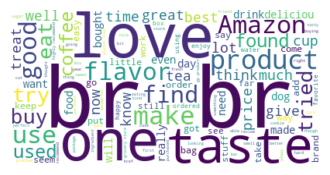

In [31]:
pos = df.loc[df.sentiment=="positive"].Text
text = " ".join(review for review in pos.astype(str))

generate_wcloud(text)

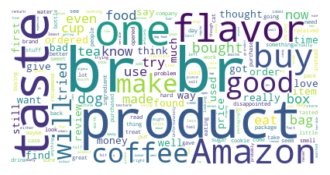

In [32]:
pos = df.loc[df.sentiment=="negative"].Text
text = " ".join(review for review in pos.astype(str))

generate_wcloud(text)

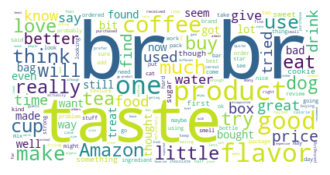

In [33]:
pos = df.loc[df.sentiment=="neutral"].Text
text = " ".join(review for review in pos.astype(str))

generate_wcloud(text)

## 18) Leakage Stress Test: Group Split by ProductId

Stricter evaluation to reduce product-level leakage:
- Train/test split uses non-overlapping ProductId groups.
- This is a more conservative estimate than random row split.

In [34]:
from sklearn.model_selection import GroupShuffleSplit

# Group-based split by ProductId (single holdout test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, test_idx = next(gss.split(df["text_clean"], df["sentiment"], groups=df["ProductId"]))

X_train_g = df.iloc[train_idx]["text_clean"]
y_train_g = df.iloc[train_idx]["sentiment"]
X_test_g = df.iloc[test_idx]["text_clean"]
y_test_g = df.iloc[test_idx]["sentiment"]

print("Group split sizes:", len(X_train_g), len(X_test_g))
print("Unique ProductId train/test overlap:", len(set(df.iloc[train_idx]["ProductId"]).intersection(set(df.iloc[test_idx]["ProductId"]))))

# Train the selected winner model under group split for robustness check
group_model = best_models[winner].best_estimator_
group_model.fit(X_train_g, y_train_g)
y_pred_g = group_model.predict(X_test_g)

print("\n=== GROUP-SPLIT TEST REPORT ===")
print(classification_report(y_test_g, y_pred_g, digits=4))
print("Macro-F1 under group split is the strict robustness metric.")

Group split sizes: 484149 82960
Unique ProductId train/test overlap: 0

=== GROUP-SPLIT TEST REPORT ===
              precision    recall  f1-score   support

    negative     0.7767    0.8194    0.7975     11725
     neutral     0.4903    0.5948    0.5375      6375
    positive     0.9641    0.9343    0.9490     64860

    accuracy                         0.8920     82960
   macro avg     0.7437    0.7829    0.7613     82960
weighted avg     0.9012    0.8920    0.8960     82960

Macro-F1 under group split is the strict robustness metric.


## 19) MongoDB Write-Back Verification (Safe)

We provide optional write-back to verify end-to-end pipeline integration with MongoDB.
Default mode is SAFE (no write). Set `ENABLE_WRITE_BACK=True` to execute.

In [35]:
ENABLE_WRITE_BACK = False
TARGET_COLLECTION_NAME = "review_decision_dashboard"

write_payload = decision_dashboard.copy()
write_payload["generated_at"] = pd.Timestamp.now("UTC")
write_docs = write_payload.head(5000).to_dict("records")  # bounded write for safety

print(f"Prepared write-back docs: {len(write_docs):,}")
print("Target collection:", TARGET_COLLECTION_NAME)

if ENABLE_WRITE_BACK:
    target_col = client[selected_db][TARGET_COLLECTION_NAME]
    target_col.delete_many({})
    target_col.insert_many(write_docs)
    written_count = target_col.count_documents({})
    sample_doc = target_col.find_one({}, {"_id": 0})
    print("Write-back complete. Stored docs:", written_count)
    print("Sample stored document keys:", list(sample_doc.keys()) if sample_doc else [])
else:
    print("SAFE MODE: No MongoDB write performed. Set ENABLE_WRITE_BACK=True to execute.")

Prepared write-back docs: 5,000
Target collection: review_decision_dashboard
SAFE MODE: No MongoDB write performed. Set ENABLE_WRITE_BACK=True to execute.


## 20) Safe Export Helper (Avoid Permission Errors)

If files are open in another app, fallback names are used automatically.

In [36]:
def safe_to_csv(df_obj, primary_name):
    try:
        df_obj.to_csv(primary_name, index=False)
        print(f"Saved: {primary_name}")
    except PermissionError:
        fallback = primary_name.replace(".csv", "_new.csv")
        df_obj.to_csv(fallback, index=False)
        print(f"PermissionError on {primary_name}; saved fallback: {fallback}")

safe_to_csv(val_df, "strict_model_validation_results.csv")
safe_to_csv(pd.DataFrame({"y_true": y_test.values, "y_pred": test_pred}), "strict_test_predictions.csv")
safe_to_csv(df[["Id", "ProductId", "Score", "sentiment", "text_clean"]], "strict_cleaned_full.csv")

safe_to_csv(monthly, "strict_monthly_trend.csv")
safe_to_csv(decision_table, "strict_decision_table_full.csv")
safe_to_csv(decision_dashboard, "strict_decision_dashboard.csv")
safe_to_csv(invest_top, "strict_top_invest.csv")
safe_to_csv(fix_top, "strict_top_fix.csv")
safe_to_csv(kill_top, "strict_top_kill_or_redesign.csv")

Saved: strict_model_validation_results.csv
Saved: strict_test_predictions.csv
Saved: strict_cleaned_full.csv
Saved: strict_monthly_trend.csv
Saved: strict_decision_table_full.csv
Saved: strict_decision_dashboard.csv
Saved: strict_top_invest.csv
Saved: strict_top_fix.csv
Saved: strict_top_kill_or_redesign.csv


## 21) Error Analysis Table (Misclassification Patterns)

This section analyzes model mistakes by class-pair direction (`y_true -> y_pred`).
It helps explain where the model fails most often and supports targeted improvement.

Why this matters:
- Accuracy alone can hide class-specific errors.
- Macro-F1 + error-pair analysis provides a more reliable quality view.
- We can prioritize mitigation for the most frequent error directions.

In [37]:
# Error Analysis Table: top misclassification pairs
import pandas as pd

# Build evaluation frame from test output
err_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": test_pred
})

# Keep only errors
err_only = err_df[err_df["y_true"] != err_df["y_pred"]].copy()

# Pair-level aggregation: true -> predicted
pair_table = (
    err_only
    .groupby(["y_true", "y_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Add percentages
total_test = len(err_df)
total_errors = len(err_only)
pair_table["pct_of_errors"] = (pair_table["count"] / total_errors * 100).round(2)
pair_table["pct_of_test"] = (pair_table["count"] / total_test * 100).round(2)

print(f"Total test samples: {total_test:,}")
print(f"Total misclassified: {total_errors:,}")
print(f"Error rate: {total_errors/total_test:.2%}")

print("\nTop misclassification pairs (y_true -> y_pred):")
display(pair_table.head(10))

Total test samples: 85,067
Total misclassified: 9,231
Error rate: 10.85%

Top misclassification pairs (y_true -> y_pred):


,y_true,y_pred,count,pct_of_errors,pct_of_test
5,positive,neutral,2603,28.20,3.06
4,positive,negative,1660,17.98,1.95
3,neutral,positive,1442,15.62,1.70
0,negative,neutral,1298,14.06,1.53
2,neutral,negative,1281,13.88,1.51
1,negative,positive,947,10.26,1.11


## 22) Slide Charts from In-Memory Pipeline Outputs (No CSV Dependency)

This section generates presentation-ready charts directly from in-memory variables created by the notebook:
- `val_df`, `y_test`, `test_pred` for model evidence
- `decision_table` for decision insights
- `monthly` for trend monitoring

Why this section:
- avoids stale/incorrect CSV outputs
- guarantees figures reflect current run logic
- exports high-resolution PNG files for slides

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1059562643.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=val_plot, x="model", y="f1_macro", palette=model_palette, ax=ax)


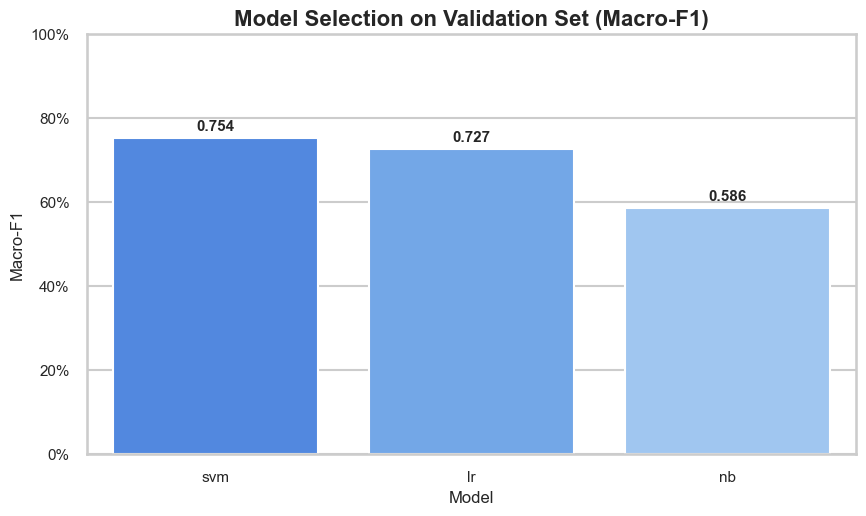

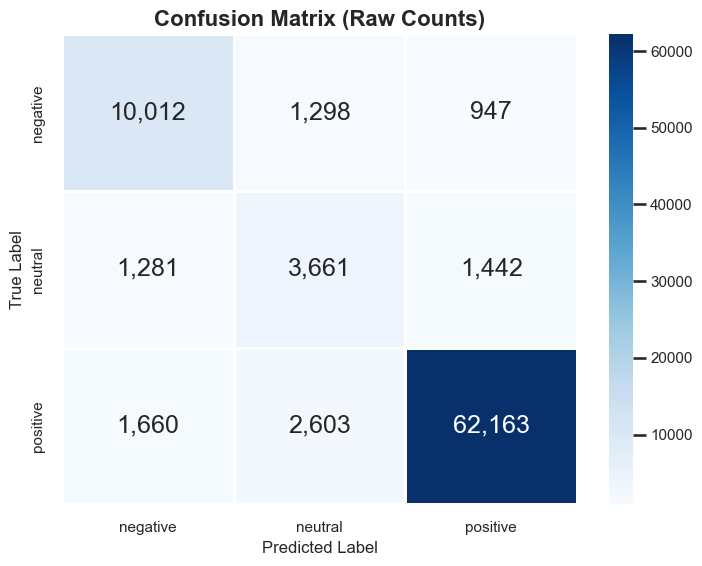

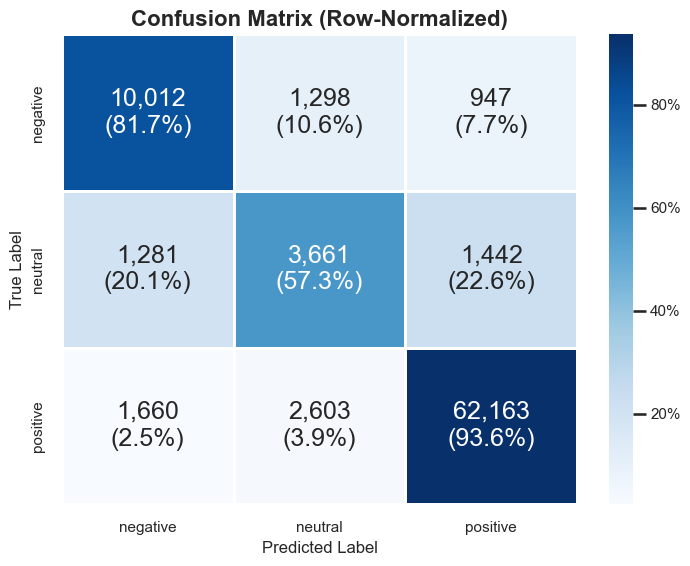

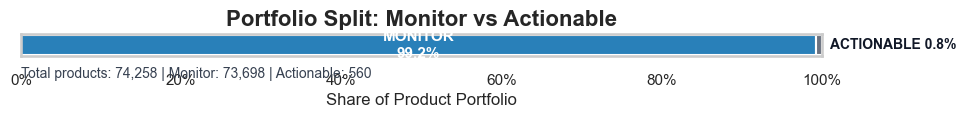

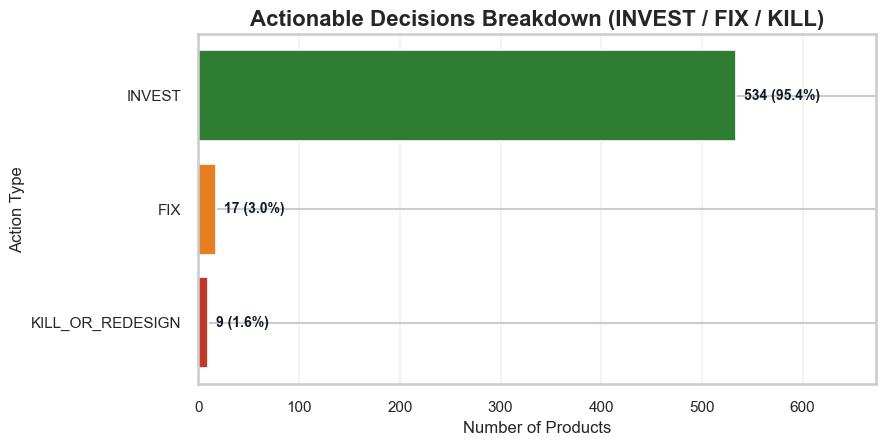

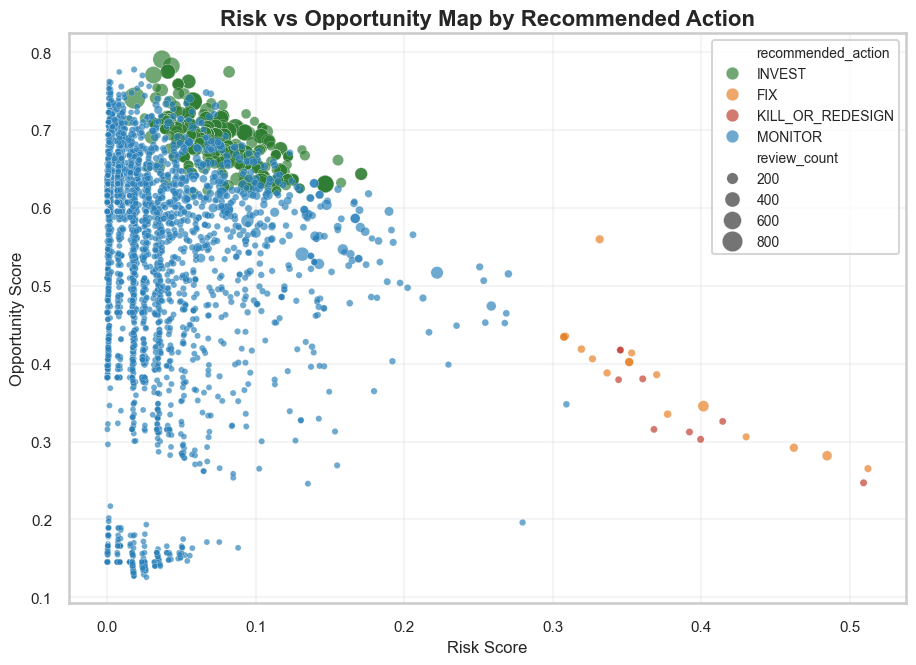

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1059562643.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaint_mean, x="aspect", y="rate", palette=reds, ax=ax)


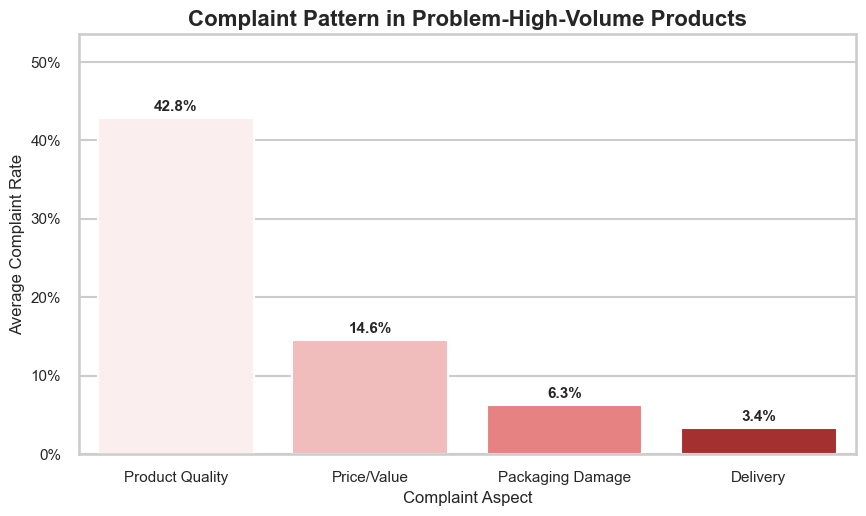

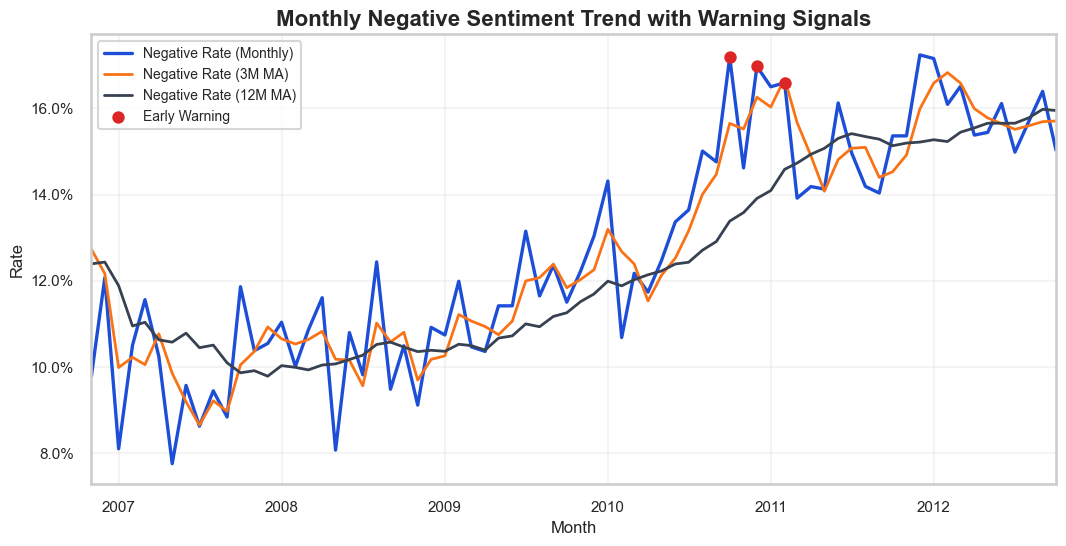

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1059562643.py:346: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


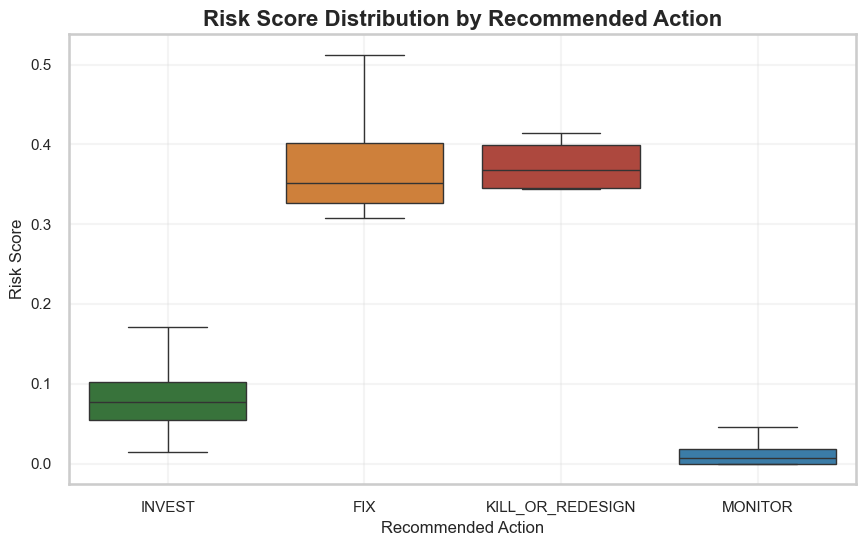

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1059562643.py:371: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


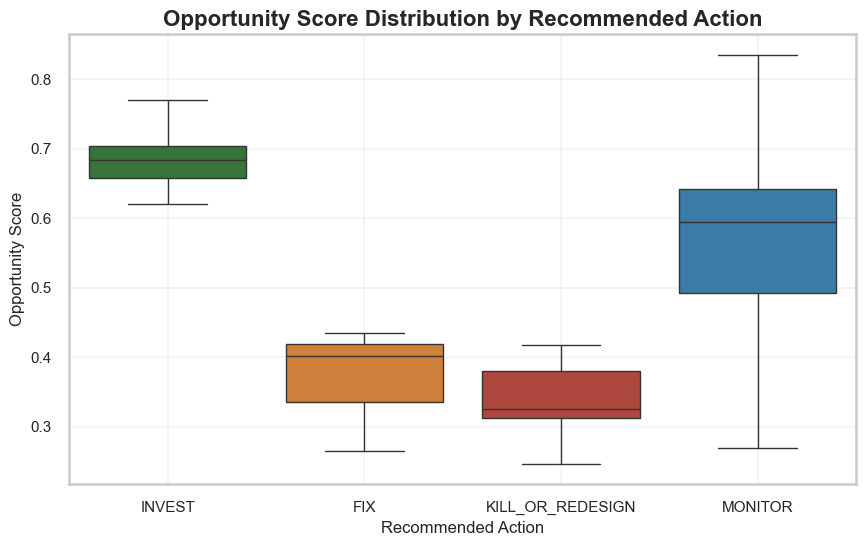

Saved polished charts to folder: strict_slide_charts
Files:
- 01_model_comparison_macro_f1.png
- 02_confusion_matrix_test.png
- 02a_confusion_matrix_raw.png
- 02b_confusion_matrix_normalized.png
- 03_action_distribution.png
- 03a_action_mix_donut.png
- 03a_portfolio_split_monitor_vs_actionable.png
- 03b_actionable_decisions_bar.png
- 03b_actionable_decisions_breakdown_horizontal.png
- 04_risk_opportunity_scatter.png
- 05_problem_group_complaint_pattern.png
- 06_monthly_neg_trend.png
- 07_boxplot_risk_by_action.png
- 08_boxplot_opportunity_by_action.png
- hidden_gem_population_bar.png
- hidden_gem_rule_scatter.png
- insight1_portfolio
- insight3_rootcause_complaint_pattern.png
- insight4_early_warning_trend.png
- insight4_monthly_warning_count.png
- insight4_pricing_by_action.png
- insight4_pricing_scatter.png
- insight_hidden_winners_budget_reallocation.png
- insight_hidden_winners_quadrant.png


In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

from sklearn.metrics import confusion_matrix

plot_dir = "strict_slide_charts"
os.makedirs(plot_dir, exist_ok=True)

# Global style for cleaner, slide-friendly visuals
if _HAS_SNS:
    sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

ACTION_ORDER = ["INVEST", "FIX", "KILL_OR_REDESIGN", "MONITOR"]
ACTION_COLORS = {
    "INVEST": "#2E7D32",
    "FIX": "#E67E22",
    "KILL_OR_REDESIGN": "#C0392B",
    "MONITOR": "#2980B9"
}


def save_show(fig, filename):
    fig.tight_layout()
    fig.savefig(os.path.join(plot_dir, filename), dpi=320, bbox_inches="tight")
    plt.show()


# 1) Model comparison (validation)
fig, ax = plt.subplots(figsize=(9, 5.5))
val_plot = val_df.sort_values("f1_macro", ascending=False).copy()
model_palette = ["#3B82F6", "#60A5FA", "#93C5FD"][: len(val_plot)]
if _HAS_SNS:
    sns.barplot(data=val_plot, x="model", y="f1_macro", palette=model_palette, ax=ax)
else:
    ax.bar(val_plot["model"], val_plot["f1_macro"], color=model_palette)

for i, v in enumerate(val_plot["f1_macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Model Selection on Validation Set (Macro-F1)")
ax.set_xlabel("Model")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save_show(fig, "01_model_comparison_macro_f1.png")


# 2A) Test confusion matrix (raw counts)
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7.5, 6))
if _HAS_SNS:
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.8,
        linecolor="white",
        ax=ax,
    )
else:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10)
    fig.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix (Raw Counts)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
save_show(fig, "02a_confusion_matrix_raw.png")


# 2B) Test confusion matrix (row-normalized)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
annot_norm = np.array([[f"{cm[i, j]:,}\n({cm_norm[i, j]:.1%})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

fig, ax = plt.subplots(figsize=(7.5, 6))
if _HAS_SNS:
    sns.heatmap(
        cm_norm,
        annot=annot_norm,
        fmt="",
        cmap="Blues",
        cbar_kws={"format": mtick.PercentFormatter(1.0)},
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.8,
        linecolor="white",
        ax=ax,
    )
else:
    im = ax.imshow(cm_norm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, annot_norm[i, j], ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
save_show(fig, "02b_confusion_matrix_normalized.png")


# 3) Action distribution (executive-ready for highly imbalanced data)
action_counts = (
    decision_table["recommended_action"]
    .value_counts()
    .reindex(ACTION_ORDER, fill_value=0)
    .reset_index()
)
action_counts.columns = ["recommended_action", "count"]
action_counts["share"] = action_counts["count"] / action_counts["count"].sum()

total_products = int(action_counts["count"].sum())
monitor_count = int(action_counts.loc[action_counts["recommended_action"] == "MONITOR", "count"].sum())
actionable_count = total_products - monitor_count
monitor_share = monitor_count / max(total_products, 1)
actionable_share = actionable_count / max(total_products, 1)

# 3A) 100% composition bar: MONITOR vs ACTIONABLE
fig, ax = plt.subplots(figsize=(10, 2.8))
segments = [monitor_share, actionable_share]
segment_labels = ["MONITOR", "ACTIONABLE"]
segment_colors = [ACTION_COLORS["MONITOR"], "#6B7280"]

left = 0.0
for seg, label, color in zip(segments, segment_labels, segment_colors):
    ax.barh([0], [seg], left=left, color=color, height=0.52, edgecolor="white", linewidth=1.5)
    if seg >= 0.06:
        ax.text(left + seg / 2, 0, f"{label}\n{seg:.1%}", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
    else:
        ax.text(left + seg + 0.01, 0, f"{label} {seg:.1%}", ha="left", va="center", color="#111827", fontsize=10, fontweight="bold")
    left += seg

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Share of Product Portfolio")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Portfolio Split: Monitor vs Actionable")
ax.grid(axis="x", alpha=0.22)

# KPI subtitle under chart
ax.text(
    0.0,
    -0.8,
    f"Total products: {total_products:,} | Monitor: {monitor_count:,} | Actionable: {actionable_count:,}",
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=10,
    color="#374151",
)
save_show(fig, "03a_portfolio_split_monitor_vs_actionable.png")

# 3B) Horizontal ranking for actionable decisions only
focus_actions = action_counts[action_counts["recommended_action"] != "MONITOR"].copy()
focus_actions["share_of_actionable"] = focus_actions["count"] / max(focus_actions["count"].sum(), 1)
focus_actions = focus_actions.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
y = np.arange(len(focus_actions))
bar_colors = [ACTION_COLORS[a] for a in focus_actions["recommended_action"]]
ax.barh(y, focus_actions["count"], color=bar_colors, edgecolor="white", linewidth=1.2)

for yi, (_, row) in zip(y, focus_actions.iterrows()):
    ax.text(
        row["count"] + max(focus_actions["count"].max() * 0.015, 1),
        yi,
        f"{int(row['count']):,} ({row['share_of_actionable']:.1%})",
        va="center",
        ha="left",
        fontsize=10,
        color="#111827",
        fontweight="bold",
    )

ax.set_yticks(y)
ax.set_yticklabels(focus_actions["recommended_action"])
ax.set_xlabel("Number of Products")
ax.set_ylabel("Action Type")
ax.set_title("Actionable Decisions Breakdown (INVEST / FIX / KILL)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", alpha=0.22)

# Clean right edge so labels are not clipped
ax.set_xlim(0, focus_actions["count"].max() * 1.26)
save_show(fig, "03b_actionable_decisions_breakdown_horizontal.png")


# 4) Risk vs opportunity scatter (sample MONITOR points to reduce overplotting)
scatter_df = decision_table.copy()
monitor_mask = scatter_df["recommended_action"] == "MONITOR"
monitor_sample = scatter_df[monitor_mask].sample(min(6000, monitor_mask.sum()), random_state=42)
focus = pd.concat([scatter_df[~monitor_mask], monitor_sample], axis=0)

fig, ax = plt.subplots(figsize=(9.5, 7))
if _HAS_SNS:
    sns.scatterplot(
        data=focus,
        x="risk_score",
        y="opportunity_score",
        hue="recommended_action",
        hue_order=ACTION_ORDER,
        palette=ACTION_COLORS,
        size="review_count",
        sizes=(18, 240),
        alpha=0.68,
        linewidth=0.2,
        edgecolor="white",
        ax=ax,
        legend="brief",
    )
else:
    for action in ACTION_ORDER:
        grp = focus[focus["recommended_action"] == action]
        if len(grp) == 0:
            continue
        ax.scatter(grp["risk_score"], grp["opportunity_score"], s=20, alpha=0.6, label=action, color=ACTION_COLORS[action])
    ax.legend(title="recommended_action")

ax.set_title("Risk vs Opportunity Map by Recommended Action")
ax.set_xlabel("Risk Score")
ax.set_ylabel("Opportunity Score")
ax.grid(alpha=0.2)
save_show(fig, "04_risk_opportunity_scatter.png")


# 5) Complaint pattern for problem_high_volume
if "business_group" in decision_table.columns:
    phv = decision_table[decision_table["business_group"] == "problem_high_volume"]
    if len(phv) > 0:
        complaint_cols = ["delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate"]
        complaint_mean = phv[complaint_cols].mean().sort_values(ascending=False).reset_index()
        complaint_mean.columns = ["aspect", "rate"]

        aspect_pretty = {
            "delivery_rate": "Delivery",
            "packaging_damage_rate": "Packaging Damage",
            "price_value_rate": "Price/Value",
            "product_quality_rate": "Product Quality",
        }
        complaint_mean["aspect"] = complaint_mean["aspect"].map(aspect_pretty)

        fig, ax = plt.subplots(figsize=(9, 5.5))
        reds = ["#FDECEC", "#F8B4B4", "#F87171", "#B91C1C"]
        if _HAS_SNS:
            sns.barplot(data=complaint_mean, x="aspect", y="rate", palette=reds, ax=ax)
        else:
            ax.bar(complaint_mean["aspect"], complaint_mean["rate"], color=reds)

        for i, v in enumerate(complaint_mean["rate"]):
            ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

        ax.set_title("Complaint Pattern in Problem-High-Volume Products")
        ax.set_xlabel("Complaint Aspect")
        ax.set_ylabel("Average Complaint Rate")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_ylim(0, max(complaint_mean["rate"]) * 1.25)
        save_show(fig, "05_problem_group_complaint_pattern.png")


# 6) Monthly trend with clean, presentation-grade date axis
trend = monthly.copy().reset_index(drop=True)

# Robust datetime parsing for both 'YYYY-MM' and full-date string inputs
trend["review_month_str"] = trend["review_month"].astype(str).str.slice(0, 7)
trend["review_month_dt"] = pd.to_datetime(trend["review_month_str"] + "-01", errors="coerce")
trend_plot = trend.dropna(subset=["review_month_dt"]).sort_values("review_month_dt").copy()

# Use a stable range to avoid noisy early periods with tiny sample sizes
if "reviews" in trend_plot.columns:
    trend_plot = trend_plot[trend_plot["reviews"] >= 100]

# Keep recent window for cleaner storytelling on slides
MAX_MONTHS_FOR_PLOT = 72
if len(trend_plot) > MAX_MONTHS_FOR_PLOT:
    trend_plot = trend_plot.tail(MAX_MONTHS_FOR_PLOT)

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(trend_plot["review_month_dt"], trend_plot["neg_rate"], label="Negative Rate (Monthly)", linewidth=2.4, color="#1D4ED8")
ax.plot(trend_plot["review_month_dt"], trend_plot["neg_rate_3m"], label="Negative Rate (3M MA)", linewidth=2.0, color="#F97316")
ax.plot(trend_plot["review_month_dt"], trend_plot["neg_rate_12m"], label="Negative Rate (12M MA)", linewidth=2.0, color="#374151")

if "early_warning" in trend_plot.columns:
    warn = trend_plot[trend_plot["early_warning"] == True]
    if len(warn) > 0:
        ax.scatter(warn["review_month_dt"], warn["neg_rate"], color="#DC2626", s=55, label="Early Warning", zorder=4)

ax.set_title("Monthly Negative Sentiment Trend with Warning Signals")
ax.set_xlabel("Month")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(alpha=0.2)

# Professional x-axis: major ticks every year, readable labels
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.tick_params(axis="x", labelrotation=0)

# Explicit x-limits prevent stray/tight label overlap
ax.set_xlim(trend_plot["review_month_dt"].min(), trend_plot["review_month_dt"].max())

ax.legend(loc="upper left")
save_show(fig, "06_monthly_neg_trend.png")


# 7) Box plot: risk score distribution by action
box_df = decision_table[decision_table["recommended_action"].isin(ACTION_ORDER)].copy()
fig, ax = plt.subplots(figsize=(9, 5.8))
if _HAS_SNS:
    sns.boxplot(
        data=box_df,
        x="recommended_action",
        y="risk_score",
        order=ACTION_ORDER,
        palette=[ACTION_COLORS[a] for a in ACTION_ORDER],
        showfliers=False,
        ax=ax,
    )
else:
    grouped = [box_df[box_df["recommended_action"] == a]["risk_score"].values for a in ACTION_ORDER]
    bp = ax.boxplot(grouped, labels=ACTION_ORDER, patch_artist=True, showfliers=False)
    for patch, a in zip(bp["boxes"], ACTION_ORDER):
        patch.set_facecolor(ACTION_COLORS[a])

ax.set_title("Risk Score Distribution by Recommended Action")
ax.set_xlabel("Recommended Action")
ax.set_ylabel("Risk Score")
ax.grid(alpha=0.2)
save_show(fig, "07_boxplot_risk_by_action.png")


# 8) Box plot: opportunity score distribution by action
fig, ax = plt.subplots(figsize=(9, 5.8))
if _HAS_SNS:
    sns.boxplot(
        data=box_df,
        x="recommended_action",
        y="opportunity_score",
        order=ACTION_ORDER,
        palette=[ACTION_COLORS[a] for a in ACTION_ORDER],
        showfliers=False,
        ax=ax,
    )
else:
    grouped = [box_df[box_df["recommended_action"] == a]["opportunity_score"].values for a in ACTION_ORDER]
    bp = ax.boxplot(grouped, labels=ACTION_ORDER, patch_artist=True, showfliers=False)
    for patch, a in zip(bp["boxes"], ACTION_ORDER):
        patch.set_facecolor(ACTION_COLORS[a])

ax.set_title("Opportunity Score Distribution by Recommended Action")
ax.set_xlabel("Recommended Action")
ax.set_ylabel("Opportunity Score")
ax.grid(alpha=0.2)
save_show(fig, "08_boxplot_opportunity_by_action.png")

print("Saved polished charts to folder:", plot_dir)
print("Files:")
for f in sorted(os.listdir(plot_dir)):
    print("-", f)

In [39]:
if "decision_table" not in globals():
    raise RuntimeError("decision_table chưa tồn tại. Hãy chạy section decision engine trước (section 13/13.5).")

top_invest_5 = (
    decision_table[decision_table["recommended_action"] == "INVEST"]
    .sort_values("action_priority", ascending=False)
    [["ProductId", "review_count", "mean_score", "risk_score", "opportunity_score", "action_priority"]]
    .head(5)
    .reset_index(drop=True)
)

top_kill_5 = (
    decision_table[decision_table["recommended_action"] == "KILL_OR_REDESIGN"]
    .sort_values("action_priority", ascending=False)
    [["ProductId", "review_count", "mean_score", "risk_score", "opportunity_score", "action_priority"]]
    .head(5)
    .reset_index(drop=True)
)

display(top_invest_5)
display(top_kill_5)

,ProductId,review_count,mean_score,risk_score,opportunity_score,action_priority
0,B000VK08OC,232,4.491379,0.081944,0.774601,0.685236
1,B003B3OOPA,623,4.739968,0.036720,0.790643,0.661891
2,B001EO5Q64,567,4.746032,0.042959,0.782191,0.660120
3,B008J1HO4C,355,4.681690,0.054662,0.762178,0.653472
4,B001EO5U3I,355,4.681690,0.054662,0.762178,0.653472


,ProductId,review_count,mean_score,risk_score,opportunity_score,action_priority
0,B00171417E,32,2.718750,0.345425,0.417444,0.724726
1,B00171417O,32,2.718750,0.345425,0.417444,0.724726
2,B000NY8OLK,38,1.315789,0.509187,0.247019,0.718395
3,B000BZ6LXO,36,2.305556,0.360461,0.380462,0.703877
4,B0099HD3YA,34,2.117647,0.414313,0.325870,0.703173


Thresholds:
score_high=4.2
vol_low(reliable q25)=39.00
HIDDEN_GEM_MIN_REVIEWS=15

Hidden gems found: 2,710


,ProductId,review_count,mean_score,pos_rate,neg_rate,risk_score,opportunity_score,recommended_action,action_priority
596,B0019QKOQY,24,4.875000,1.000000,0.000000,0.033415,0.782431,MONITOR,0.244754
581,B000EDK5LM,29,4.896552,1.000000,0.000000,0.057266,0.770716,MONITOR,0.248395
589,B000EDM8FS,31,4.870968,0.967742,0.000000,0.053794,0.765161,MONITOR,0.245686
647,B000F3WS7K,30,4.866667,1.000000,0.000000,0.040973,0.762661,MONITOR,0.241090
770,B000Q9TSIU,15,4.933333,1.000000,0.000000,0.024795,0.759529,MONITOR,0.235297
610,B0007UQ73W,27,4.851852,0.962963,0.037037,0.051985,0.757517,MONITOR,0.242851
677,B000ED7MDQ,25,4.840000,0.960000,0.000000,0.039055,0.755520,MONITOR,0.238372
814,B0038ZS6PU,19,4.947368,1.000000,0.000000,0.026147,0.753964,MONITOR,0.234033
605,B000FIAWVE,35,4.885714,1.000000,0.000000,0.057799,0.753838,MONITOR,0.243491
737,B000EICPAG,18,4.888889,1.000000,0.000000,0.033921,0.753322,MONITOR,0.236173


Saved: hidden_gem_top20.csv, hidden_gem_all.csv


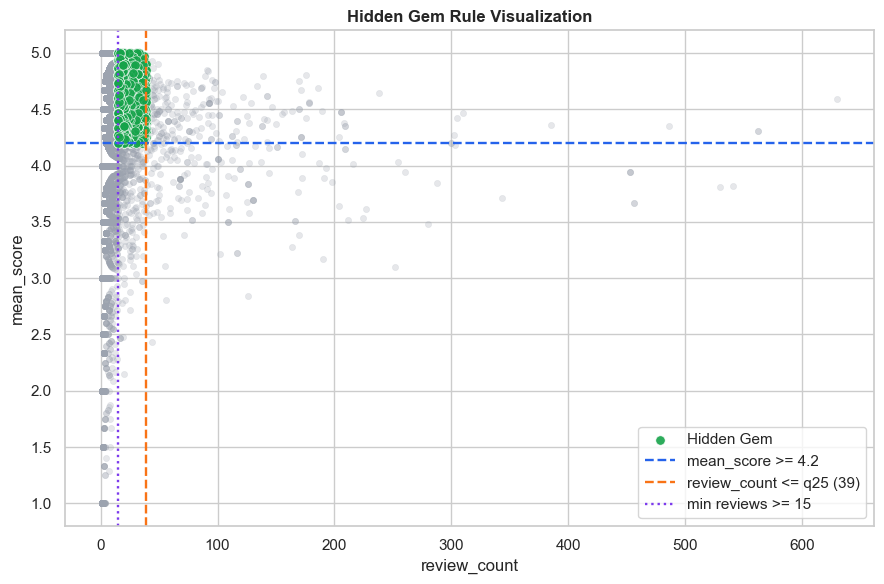

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\3075372975.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=count_df, x="group", y="count", palette=colors, ax=ax)


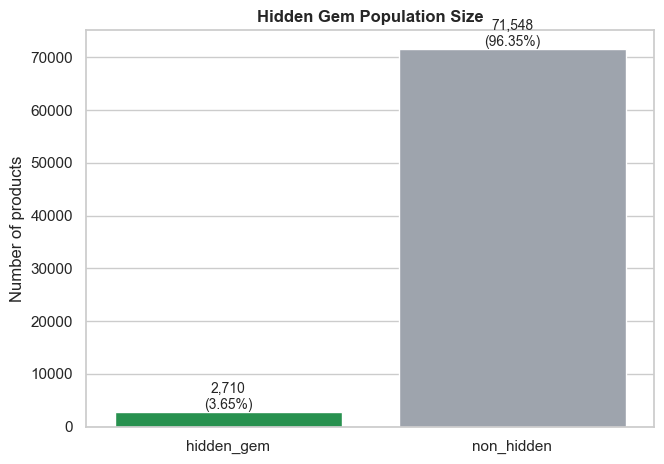

Saved figures:
- strict_slide_charts\hidden_gem_rule_scatter.png
- strict_slide_charts\hidden_gem_population_bar.png


In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SNS = False

# ---------- 0) Parameters ----------
# Reuse if already defined
if "MIN_REVIEWS" not in globals():
    MIN_REVIEWS = 30

if "HIDDEN_GEM_MIN_REVIEWS" not in globals():
    HIDDEN_GEM_MIN_REVIEWS = max(10, int(MIN_REVIEWS * 0.5))

score_high = 4.2

# Reliable subset for quantiles
reliable = decision_table[decision_table["review_count"] >= MIN_REVIEWS].copy()
if len(reliable) > 0:
    vol_low = reliable["review_count"].quantile(0.25)
else:
    vol_low = decision_table["review_count"].quantile(0.25)

# ---------- 1) Define hidden_gem flag ----------
hidden_mask = (
    (decision_table["mean_score"] >= score_high) &
    (decision_table["review_count"] <= vol_low) &
    (decision_table["review_count"] >= HIDDEN_GEM_MIN_REVIEWS)
)

hidden_df = decision_table[hidden_mask].copy()
non_hidden_df = decision_table[~hidden_mask].copy()

print("Thresholds:")
print(f"score_high={score_high}")
print(f"vol_low(reliable q25)={vol_low:.2f}")
print(f"HIDDEN_GEM_MIN_REVIEWS={HIDDEN_GEM_MIN_REVIEWS}")
print(f"\nHidden gems found: {len(hidden_df):,}")

# ---------- 2) TABLE export ----------
table_cols = [
    "ProductId", "review_count", "mean_score",
    "pos_rate", "neg_rate", "risk_score",
    "opportunity_score", "recommended_action", "action_priority"
]
hidden_top20 = hidden_df.sort_values("opportunity_score", ascending=False)[table_cols].head(20)

display(hidden_top20)

hidden_top20.to_csv("hidden_gem_top20.csv", index=False)
hidden_df[table_cols].sort_values("opportunity_score", ascending=False).to_csv("hidden_gem_all.csv", index=False)
print("Saved: hidden_gem_top20.csv, hidden_gem_all.csv")

# ---------- 3) FIGURES ----------
out_dir = "strict_slide_charts"
os.makedirs(out_dir, exist_ok=True)

# 3A. Scatter with threshold lines
plot_df = decision_table.copy()

# Optional downsample for readability
sample_size = 12000
if len(plot_df) > sample_size:
    plot_df = plot_df.sample(sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

if HAS_SNS:
    sns.scatterplot(
        data=plot_df,
        x="review_count", y="mean_score",
        color="#9CA3AF", alpha=0.25, s=20, edgecolor=None, ax=ax
    )
else:
    ax.scatter(plot_df["review_count"], plot_df["mean_score"], alpha=0.25, s=20, color="#9CA3AF")

# Overlay hidden gems
if HAS_SNS and len(hidden_df) > 0:
    sns.scatterplot(
        data=hidden_df,
        x="review_count", y="mean_score",
        color="#16A34A", alpha=0.9, s=45, edgecolor="white", linewidth=0.4, ax=ax, label="Hidden Gem"
    )
elif len(hidden_df) > 0:
    ax.scatter(hidden_df["review_count"], hidden_df["mean_score"], color="#16A34A", s=45, alpha=0.9, label="Hidden Gem")

# Threshold lines
ax.axhline(score_high, color="#2563EB", linestyle="--", linewidth=1.7, label=f"mean_score >= {score_high}")
ax.axvline(vol_low, color="#F97316", linestyle="--", linewidth=1.7, label=f"review_count <= q25 ({vol_low:.0f})")
ax.axvline(HIDDEN_GEM_MIN_REVIEWS, color="#7C3AED", linestyle=":", linewidth=1.7, label=f"min reviews >= {HIDDEN_GEM_MIN_REVIEWS}")

ax.set_title("Hidden Gem Rule Visualization")
ax.set_xlabel("review_count")
ax.set_ylabel("mean_score")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "hidden_gem_rule_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3B. Count bar: Hidden vs Non-hidden
count_df = pd.DataFrame({
    "group": ["hidden_gem", "non_hidden"],
    "count": [len(hidden_df), len(non_hidden_df)]
})
count_df["share"] = count_df["count"] / max(count_df["count"].sum(), 1)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
colors = ["#16A34A", "#9CA3AF"]

if HAS_SNS:
    sns.barplot(data=count_df, x="group", y="count", palette=colors, ax=ax)
else:
    ax.bar(count_df["group"], count_df["count"], color=colors)

for i, row in count_df.iterrows():
    ax.text(i, row["count"], f"{row['count']:,}\n({row['share']:.2%})", ha="center", va="bottom", fontsize=10)

ax.set_title("Hidden Gem Population Size")
ax.set_xlabel("")
ax.set_ylabel("Number of products")
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "hidden_gem_population_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("-", os.path.join(out_dir, "hidden_gem_rule_scatter.png"))
print("-", os.path.join(out_dir, "hidden_gem_population_bar.png"))

Hidden winners identified: 2,710
Avg hidden mean_score: 4.548
Avg hidden risk_score: 0.049
Risk lower than portfolio average: -174.0%


,ProductId,review_count,mean_score,pos_rate,risk_score,opportunity_score,recommended_action
596,B0019QKOQY,24,4.875000,1.000000,0.033415,0.782431,MONITOR
581,B000EDK5LM,29,4.896552,1.000000,0.057266,0.770716,MONITOR
589,B000EDM8FS,31,4.870968,0.967742,0.053794,0.765161,MONITOR
647,B000F3WS7K,30,4.866667,1.000000,0.040973,0.762661,MONITOR
770,B000Q9TSIU,15,4.933333,1.000000,0.024795,0.759529,MONITOR


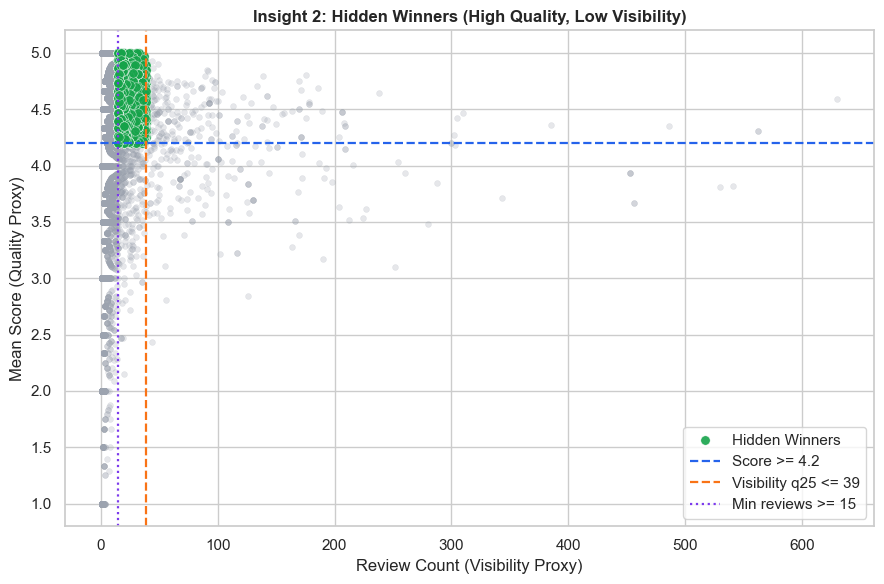

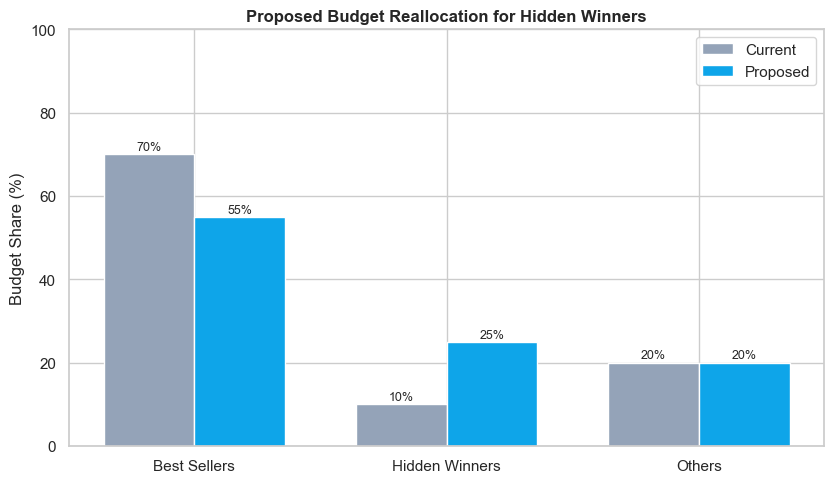

Saved:
- insight_hidden_winners_top5.csv
- strict_slide_charts/insight_hidden_winners_quadrant.png
- strict_slide_charts/insight_hidden_winners_budget_reallocation.png


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

out_dir = "strict_slide_charts"
os.makedirs(out_dir, exist_ok=True)

# ---- Parameters (reuse from notebook if available) ----
if "MIN_REVIEWS" not in globals():
    MIN_REVIEWS = 30
if "HIDDEN_GEM_MIN_REVIEWS" not in globals():
    HIDDEN_GEM_MIN_REVIEWS = max(10, int(MIN_REVIEWS * 0.5))

score_high = 4.2

reliable = decision_table[decision_table["review_count"] >= MIN_REVIEWS].copy()
vol_low = reliable["review_count"].quantile(0.25) if len(reliable) else decision_table["review_count"].quantile(0.25)

# ---- Hidden winner rule ----
hidden_mask = (
    (decision_table["mean_score"] >= score_high) &
    (decision_table["review_count"] <= vol_low) &
    (decision_table["review_count"] >= HIDDEN_GEM_MIN_REVIEWS)
)

hidden_df = decision_table[hidden_mask].copy()
hidden_df["insight_group"] = "hidden_winner"
decision_table["insight_group"] = np.where(hidden_mask, "hidden_winner", "other")

# ---- Evidence numbers for slide text ----
avg_score_hidden = hidden_df["mean_score"].mean() if len(hidden_df) else np.nan
avg_risk_hidden = hidden_df["risk_score"].mean() if len(hidden_df) else np.nan
avg_risk_all = decision_table["risk_score"].mean()
risk_gap = (avg_risk_all - avg_risk_hidden) / avg_risk_all if avg_risk_all > 0 and len(hidden_df) else np.nan

print(f"Hidden winners identified: {len(hidden_df):,}")
print(f"Avg hidden mean_score: {avg_score_hidden:.3f}")
print(f"Avg hidden risk_score: {avg_risk_hidden:.3f}")
print(f"Risk lower than portfolio average: {risk_gap:.1%}" if pd.notna(risk_gap) else "Risk gap: N/A")

# ---- TABLE: top hidden winners ----
cols = [
    "ProductId", "review_count", "mean_score", "pos_rate",
    "risk_score", "opportunity_score", "recommended_action"
]
hidden_top5 = hidden_df.sort_values("opportunity_score", ascending=False)[cols].head(5).copy()
display(hidden_top5)

hidden_top5.to_csv("insight_hidden_winners_top5.csv", index=False)

# ---- FIGURE 1: quadrant scatter ----
plot_df = decision_table.copy()
if len(plot_df) > 12000:
    plot_df = plot_df.sample(12000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
if sns:
    sns.scatterplot(
        data=plot_df, x="review_count", y="mean_score",
        color="#9CA3AF", alpha=0.25, s=18, edgecolor=None, ax=ax
    )
    if len(hidden_df):
        sns.scatterplot(
            data=hidden_df, x="review_count", y="mean_score",
            color="#16A34A", alpha=0.9, s=45, edgecolor="white", linewidth=0.3, ax=ax, label="Hidden Winners"
        )
else:
    ax.scatter(plot_df["review_count"], plot_df["mean_score"], color="#9CA3AF", alpha=0.25, s=18)
    if len(hidden_df):
        ax.scatter(hidden_df["review_count"], hidden_df["mean_score"], color="#16A34A", alpha=0.9, s=45, label="Hidden Winners")

ax.axhline(score_high, color="#2563EB", linestyle="--", linewidth=1.6, label=f"Score >= {score_high}")
ax.axvline(vol_low, color="#F97316", linestyle="--", linewidth=1.6, label=f"Visibility q25 <= {vol_low:.0f}")
ax.axvline(HIDDEN_GEM_MIN_REVIEWS, color="#7C3AED", linestyle=":", linewidth=1.6, label=f"Min reviews >= {HIDDEN_GEM_MIN_REVIEWS}")

ax.set_title("Insight 2: Hidden Winners (High Quality, Low Visibility)")
ax.set_xlabel("Review Count (Visibility Proxy)")
ax.set_ylabel("Mean Score (Quality Proxy)")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight_hidden_winners_quadrant.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- FIGURE 2: budget reallocation illustration ----
# Example percentages for storytelling; adjust to your strategy
current = {"Best Sellers": 70, "Hidden Winners": 10, "Others": 20}
proposed = {"Best Sellers": 55, "Hidden Winners": 25, "Others": 20}

labels = list(current.keys())
x = np.arange(len(labels))
w = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(x - w/2, [current[k] for k in labels], width=w, label="Current", color="#94A3B8")
ax.bar(x + w/2, [proposed[k] for k in labels], width=w, label="Proposed", color="#0EA5E9")

for i, k in enumerate(labels):
    ax.text(i - w/2, current[k] + 1, f"{current[k]}%", ha="center", fontsize=9)
    ax.text(i + w/2, proposed[k] + 1, f"{proposed[k]}%", ha="center", fontsize=9)

ax.set_title("Proposed Budget Reallocation for Hidden Winners")
ax.set_ylabel("Budget Share (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight_hidden_winners_budget_reallocation.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("- insight_hidden_winners_top5.csv")
print("- strict_slide_charts/insight_hidden_winners_quadrant.png")
print("- strict_slide_charts/insight_hidden_winners_budget_reallocation.png")

Insight 3

Table 1 - Complaint Summary (problem_high_volume):


,aspect,mean_rate,mean_rate_pct
0,product_quality_rate,0.428093,42.81
1,price_value_rate,0.145841,14.58
2,packaging_damage_rate,0.062972,6.30
3,delivery_rate,0.033573,3.36


Saved: insight3_problem_rootcause_summary.csv

Table 2 - Top 10 problem_high_volume products:


,ProductId,review_count,mean_score,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,risk_score,opportunity_score,recommended_action,action_priority
3,B006N3I69A,131,1.343511,0.000000,0.038168,0.221374,0.274809,0.484608,0.281791,FIX,0.766398
8,B000X1Q1G8,184,1.695652,0.021739,0.010870,0.086957,0.565217,0.401354,0.345446,FIX,0.746800
597,B004JRXZKM,160,3.143750,0.068750,0.243750,0.075000,0.462500,0.287094,0.527791,MONITOR,0.244465
646,B004Q3LBTG,190,3.168421,0.100000,0.057895,0.131579,0.178947,0.257470,0.546571,MONITOR,0.241212
907,B0083T5TAQ,286,3.045455,0.087413,0.143357,0.132867,0.202797,0.273840,0.501786,MONITOR,0.232688
908,B004OAZ36I,286,3.045455,0.087413,0.143357,0.132867,0.202797,0.273840,0.501786,MONITOR,0.232688
1543,B000EVQWKC,117,2.880342,0.051282,0.042735,0.111111,0.418803,0.277950,0.476247,MONITOR,0.226259
1714,B001M08YZA,109,2.834862,0.055046,0.000000,0.146789,0.449541,0.277684,0.472386,MONITOR,0.225021
1856,B006Q820X0,252,3.099206,0.055556,0.059524,0.194444,0.488095,0.228366,0.518781,MONITOR,0.224144
2276,B002DHTWNO,171,3.116959,0.029240,0.070175,0.269006,0.567251,0.235828,0.503686,MONITOR,0.221854


Saved: insight3_problem_rootcause_top10_products.csv


C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\2279140655.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="aspect_pretty", y="mean_rate", palette="Reds", ax=ax)


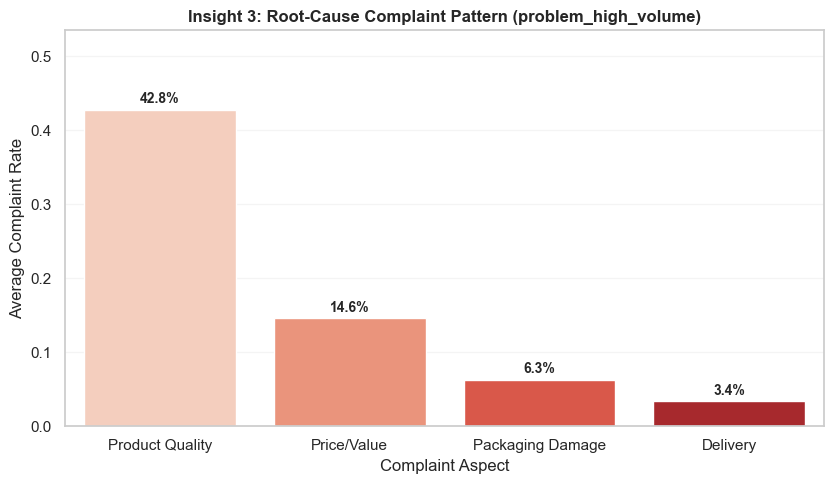

Saved figure: strict_slide_charts/insight3_rootcause_complaint_pattern.png


In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SNS = False

out_dir = "strict_slide_charts"
os.makedirs(out_dir, exist_ok=True)

# 0) Safety checks
required_cols = [
    "business_group", "ProductId", "review_count", "mean_score",
    "delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate",
    "risk_score", "opportunity_score", "recommended_action", "action_priority"
]
missing = [c for c in required_cols if c not in decision_table.columns]
if missing:
    raise RuntimeError(f"decision_table thiếu cột: {missing}. Hãy chạy section decision + 13.5 trước.")

# 1) Filter problem_high_volume
phv = decision_table[decision_table["business_group"] == "problem_high_volume"].copy()
if len(phv) == 0:
    raise RuntimeError("Không có product nào trong nhóm problem_high_volume ở run hiện tại.")

# 2) TABLE 1: Complaint summary (mean)
complaint_cols = ["delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate"]
summary_tbl = (
    phv[complaint_cols]
    .mean()
    .sort_values(ascending=False)
    .rename("mean_rate")
    .reset_index()
    .rename(columns={"index": "aspect"})
)

# format % for slide
summary_tbl["mean_rate_pct"] = (summary_tbl["mean_rate"] * 100).round(2)

print("Table 1 - Complaint Summary (problem_high_volume):")
display(summary_tbl)

summary_tbl.to_csv("insight3_problem_rootcause_summary.csv", index=False)
print("Saved: insight3_problem_rootcause_summary.csv")

# 3) TABLE 2: Top products needing root-cause fix
top_cols = [
    "ProductId", "review_count", "mean_score",
    "delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate",
    "risk_score", "opportunity_score", "recommended_action", "action_priority"
]
top_phv = (
    phv[top_cols]
    .sort_values("action_priority", ascending=False)
    .head(10)
    .copy()
)

print("\nTable 2 - Top 10 problem_high_volume products:")
display(top_phv)

top_phv.to_csv("insight3_problem_rootcause_top10_products.csv", index=False)
print("Saved: insight3_problem_rootcause_top10_products.csv")

# 4) FIGURE: Bar chart root-cause pattern
pretty = {
    "delivery_rate": "Delivery",
    "packaging_damage_rate": "Packaging Damage",
    "price_value_rate": "Price/Value",
    "product_quality_rate": "Product Quality"
}
plot_df = summary_tbl.copy()
plot_df["aspect_pretty"] = plot_df["aspect"].map(pretty)

fig, ax = plt.subplots(figsize=(8.5, 5))
if HAS_SNS:
    sns.barplot(data=plot_df, x="aspect_pretty", y="mean_rate", palette="Reds", ax=ax)
else:
    ax.bar(plot_df["aspect_pretty"], plot_df["mean_rate"], color=["#fca5a5","#f87171","#ef4444","#b91c1c"])

for i, v in enumerate(plot_df["mean_rate"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Insight 3: Root-Cause Complaint Pattern (problem_high_volume)")
ax.set_xlabel("Complaint Aspect")
ax.set_ylabel("Average Complaint Rate")
ax.set_ylim(0, plot_df["mean_rate"].max() * 1.25)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight3_rootcause_complaint_pattern.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_dir}/insight3_rootcause_complaint_pattern.png")

Insight 4

Pricing complaint threshold (q75): 0.2400
Pricing candidates found: 787

Top pricing strategy candidates:


,ProductId,review_count,mean_score,price_value_rate,risk_score,opportunity_score,recommended_action,action_priority
0,B002GWH6MA,31,4.032258,0.612903,0.096556,0.575582,MONITOR,0.201641
1,B0018CE6DQ,36,4.194444,0.611111,0.121952,0.610033,MONITOR,0.219596
2,B0019FOZC4,44,4.522727,0.568182,0.053482,0.696488,MONITOR,0.224991
3,B0002NVKZ4,32,4.531250,0.562500,0.103436,0.673218,MONITOR,0.232996
4,B001ELLB16,34,4.205882,0.558824,0.115571,0.643097,MONITOR,0.227600
5,B002WDCFFG,34,4.058824,0.558824,0.098467,0.628692,MONITOR,0.218148
6,B000ARWL46,34,4.264706,0.558824,0.067163,0.633983,MONITOR,0.210344
7,B001KYATH4,34,4.264706,0.558824,0.067163,0.633983,MONITOR,0.210344
8,B0009X0RA6,66,4.242424,0.545455,0.132500,0.674494,MONITOR,0.242098
9,B0044MTGHI,50,4.880000,0.540000,0.058026,0.768282,MONITOR,0.247892


Saved: insight4_pricing_top15_candidates.csv, insight4_pricing_all_candidates.csv

Pricing insight summary:


,metric,value
0,n_candidates,787.000000
1,avg_review_count,80.409149
2,avg_mean_score,4.233753
3,avg_price_value_rate,0.325798
4,avg_risk_score,0.101989
5,avg_opportunity_score,0.637107


Saved: insight4_pricing_summary.csv


C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\2448152417.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot1, x="recommended_action", y="price_value_rate", palette="Oranges", ax=ax)


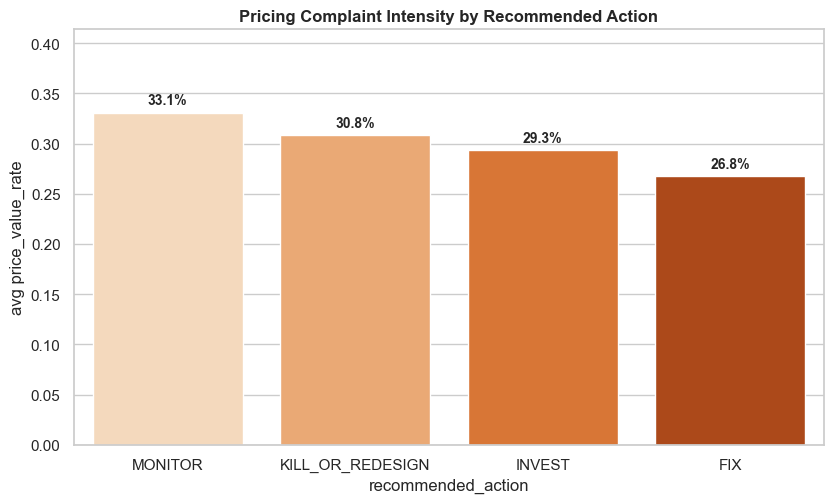

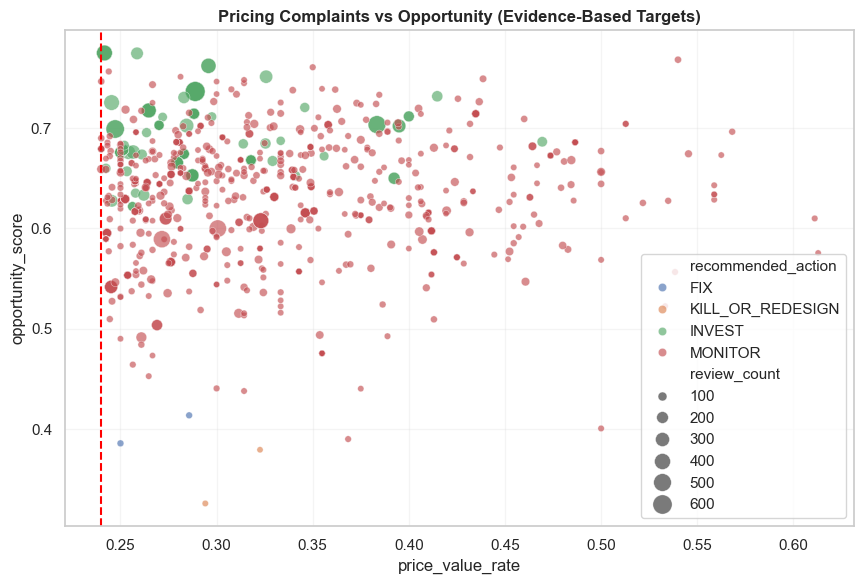

Saved figures:
- strict_slide_charts\insight4_pricing_by_action.png
- strict_slide_charts\insight4_pricing_scatter.png


In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SNS = False

out_dir = "strict_slide_charts"
os.makedirs(out_dir, exist_ok=True)

# ---------- Safety ----------
needed_cols = [
    "ProductId", "review_count", "mean_score", "price_value_rate",
    "risk_score", "opportunity_score", "recommended_action", "action_priority"
]
missing = [c for c in needed_cols if c not in decision_table.columns]
if missing:
    raise RuntimeError(f"decision_table thiếu cột: {missing}. Hãy chạy section decision engine trước.")

if "MIN_REVIEWS" not in globals():
    MIN_REVIEWS = 30

# ---------- Rule for pricing-risk candidates ----------
# Focus on products with enough evidence + elevated price/value complaints
reliable = decision_table[decision_table["review_count"] >= MIN_REVIEWS].copy()

# Dynamic threshold: top 25% by price_value_rate in reliable set
pv_q75 = reliable["price_value_rate"].quantile(0.75) if len(reliable) else decision_table["price_value_rate"].quantile(0.75)

pricing_candidates = decision_table[
    (decision_table["review_count"] >= MIN_REVIEWS) &
    (decision_table["price_value_rate"] >= pv_q75)
].copy()

print(f"Pricing complaint threshold (q75): {pv_q75:.4f}")
print(f"Pricing candidates found: {len(pricing_candidates):,}")

# ---------- TABLE 1: Top pricing candidates ----------
table_cols = [
    "ProductId", "review_count", "mean_score",
    "price_value_rate", "risk_score", "opportunity_score",
    "recommended_action", "action_priority"
]
top_pricing_15 = (
    pricing_candidates[table_cols]
    .sort_values(["price_value_rate", "action_priority"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

print("\nTop pricing strategy candidates:")
display(top_pricing_15)

top_pricing_15.to_csv("insight4_pricing_top15_candidates.csv", index=False)
pricing_candidates[table_cols].to_csv("insight4_pricing_all_candidates.csv", index=False)
print("Saved: insight4_pricing_top15_candidates.csv, insight4_pricing_all_candidates.csv")

# ---------- TABLE 2: Segment summary ----------
summary_tbl = pd.DataFrame({
    "metric": [
        "n_candidates",
        "avg_review_count",
        "avg_mean_score",
        "avg_price_value_rate",
        "avg_risk_score",
        "avg_opportunity_score"
    ],
    "value": [
        len(pricing_candidates),
        pricing_candidates["review_count"].mean() if len(pricing_candidates) else np.nan,
        pricing_candidates["mean_score"].mean() if len(pricing_candidates) else np.nan,
        pricing_candidates["price_value_rate"].mean() if len(pricing_candidates) else np.nan,
        pricing_candidates["risk_score"].mean() if len(pricing_candidates) else np.nan,
        pricing_candidates["opportunity_score"].mean() if len(pricing_candidates) else np.nan,
    ]
})

print("\nPricing insight summary:")
display(summary_tbl)

summary_tbl.to_csv("insight4_pricing_summary.csv", index=False)
print("Saved: insight4_pricing_summary.csv")

# ---------- FIGURE 1: price-value complaint by action ----------
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot1 = (
    pricing_candidates.groupby("recommended_action")["price_value_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

if HAS_SNS:
    sns.barplot(data=plot1, x="recommended_action", y="price_value_rate", palette="Oranges", ax=ax)
else:
    ax.bar(plot1["recommended_action"], plot1["price_value_rate"], color="#f59e0b")

for i, v in enumerate(plot1["price_value_rate"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Pricing Complaint Intensity by Recommended Action")
ax.set_xlabel("recommended_action")
ax.set_ylabel("avg price_value_rate")
ax.set_ylim(0, max(plot1["price_value_rate"]) * 1.25 if len(plot1) else 1)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight4_pricing_by_action.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---------- FIGURE 2: pricing complaints vs opportunity ----------
fig, ax = plt.subplots(figsize=(8.8, 6))
plot2 = pricing_candidates.copy()

# Optional downsample for readability
if len(plot2) > 6000:
    plot2 = plot2.sample(6000, random_state=42)

if HAS_SNS:
    sns.scatterplot(
        data=plot2,
        x="price_value_rate",
        y="opportunity_score",
        hue="recommended_action",
        size="review_count",
        sizes=(20, 200),
        alpha=0.65,
        ax=ax
    )
else:
    for action, grp in plot2.groupby("recommended_action"):
        ax.scatter(grp["price_value_rate"], grp["opportunity_score"], s=25, alpha=0.6, label=action)
    ax.legend()

ax.axvline(pv_q75, color="red", linestyle="--", linewidth=1.5, label=f"price_value q75={pv_q75:.2f}")
ax.set_title("Pricing Complaints vs Opportunity (Evidence-Based Targets)")
ax.set_xlabel("price_value_rate")
ax.set_ylabel("opportunity_score")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight4_pricing_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("-", os.path.join(out_dir, "insight4_pricing_by_action.png"))
print("-", os.path.join(out_dir, "insight4_pricing_scatter.png"))

Early warning rule:
neg_rate_3m > neg_rate_12m + 0.02
Persistence: 2 consecutive months
Original warnings: 27
Strict warnings:   17


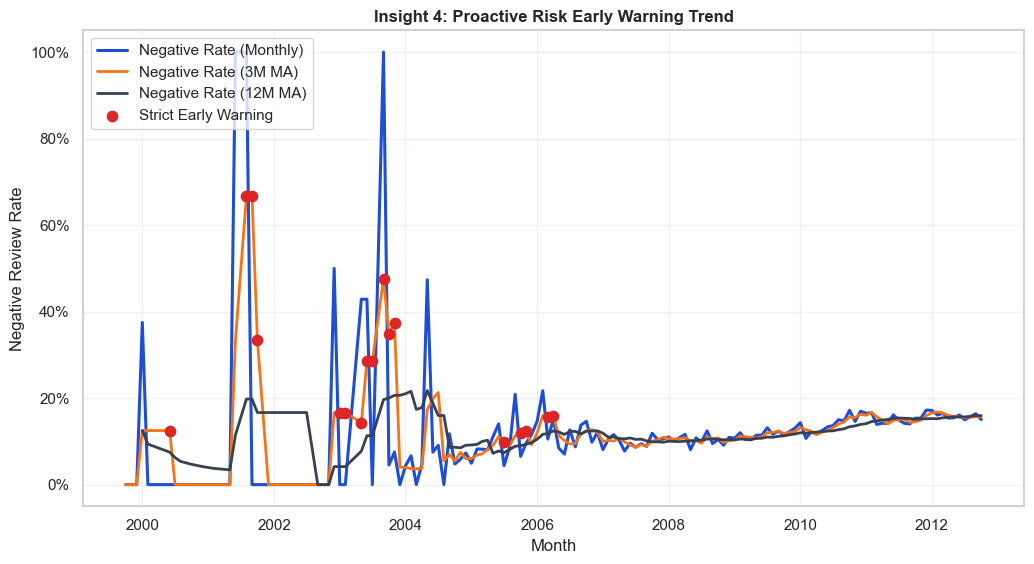

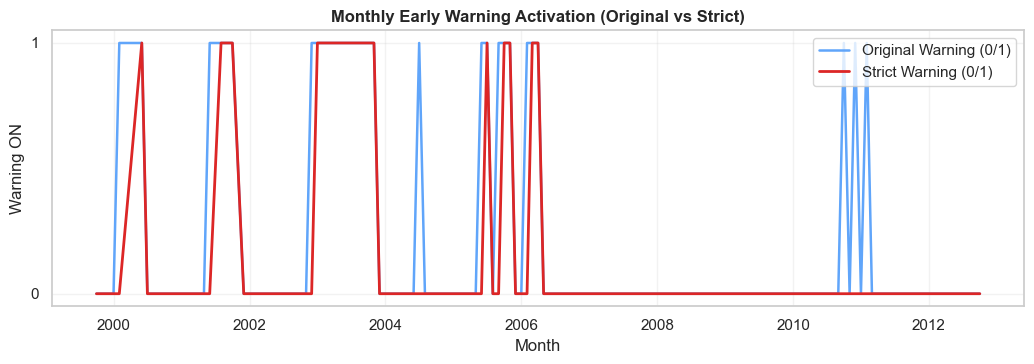

Table A - Warning months (strict):


,review_month,neg_rate,neg_rate_3m,neg_rate_12m,warning_gap
12,2001-08,1.000000,0.666667,0.197917,0.468750
13,2001-09,0.000000,0.666667,0.197917,0.468750
33,2003-09,1.000000,0.476190,0.196429,0.279762
32,2003-07,0.000000,0.285714,0.113095,0.172619
31,2003-06,0.428571,0.285714,0.113095,0.172619
35,2003-11,0.075472,0.373642,0.206506,0.167136
14,2001-10,0.000000,0.333333,0.166667,0.166667
34,2003-10,0.045455,0.348485,0.200216,0.148268
28,2003-01,0.000000,0.166667,0.041667,0.125000
29,2003-02,0.000000,0.166667,0.041667,0.125000


Saved: insight4_warning_months_strict.csv
Table B - Top products for proactive risk intervention:


,ProductId,review_count,mean_score,risk_score,opportunity_score,delivery_rate,packaging_damage_rate,price_value_rate,product_quality_rate,recommended_action,action_priority
0,B0002DH5MG,43,1.372093,0.512152,0.265221,0.023256,0.139535,0.023256,0.000000,FIX,0.777373
1,B000NY8OLK,38,1.315789,0.509187,0.247019,0.000000,0.052632,0.236842,0.421053,KILL_OR_REDESIGN,0.718395
2,B006N3I69A,131,1.343511,0.484608,0.281791,0.000000,0.038168,0.221374,0.274809,FIX,0.766398
3,B004H3N2LU,83,1.373494,0.462260,0.292052,0.012048,0.012048,0.180723,0.337349,FIX,0.754312
4,B001M050T8,42,1.785714,0.430139,0.306027,0.000000,0.023810,0.190476,0.404762,FIX,0.736166
5,B0099HD3YA,34,2.117647,0.414313,0.325870,0.147059,0.088235,0.294118,0.147059,KILL_OR_REDESIGN,0.703173
6,B000X1Q1G8,184,1.695652,0.401354,0.345446,0.021739,0.010870,0.086957,0.565217,FIX,0.746800
7,B00002N8SM,38,1.789474,0.399455,0.302842,0.078947,0.000000,0.078947,0.000000,KILL_OR_REDESIGN,0.667182
8,B002EAN3T4,25,1.520000,0.396687,0.270905,0.040000,0.040000,0.160000,0.240000,MONITOR,0.200278
9,B00346J8BO,27,1.592593,0.394786,0.276228,0.037037,0.000000,0.148148,0.629630,MONITOR,0.201304


Saved: insight4_top_warning_products.csv

Saved figures:
- strict_slide_charts\insight4_early_warning_trend.png
- strict_slide_charts\insight4_monthly_warning_count.png


In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SNS = False

out_dir = "strict_slide_charts"
os.makedirs(out_dir, exist_ok=True)

# ===============================
# 0) Safety checks
# ===============================
if "monthly" not in globals():
    raise RuntimeError("monthly chưa tồn tại. Hãy chạy section Time Trend and Early Warning trước.")

if "df" not in globals():
    raise RuntimeError("df chưa tồn tại. Hãy chạy các section preprocessing + scoring trước.")

if "decision_table" not in globals():
    raise RuntimeError("decision_table chưa tồn tại. Hãy chạy section decision engine trước.")

needed_monthly = ["review_month", "neg_rate", "neg_rate_3m", "neg_rate_12m"]
miss_m = [c for c in needed_monthly if c not in monthly.columns]
if miss_m:
    raise RuntimeError(f"monthly thiếu cột: {miss_m}")

# ===============================
# 1) Define stricter early warning rule
# ===============================
# You can tune these for sensitivity
DELTA = 0.02              # 2 percentage points
PERSIST_MONTHS = 2        # warning must persist at least 2 consecutive months

m = monthly.copy()
m["review_month_dt"] = pd.to_datetime(m["review_month"].astype(str).str[:7] + "-01", errors="coerce")
m = m.dropna(subset=["review_month_dt"]).sort_values("review_month_dt").reset_index(drop=True)

# Base warning: short-term neg rate above long-term baseline by DELTA
m["warn_base"] = (m["neg_rate_3m"] > (m["neg_rate_12m"] + DELTA))

# Persistence check: rolling window on base warning
m["warn_persist"] = (
    m["warn_base"]
    .astype(int)
    .rolling(window=PERSIST_MONTHS, min_periods=PERSIST_MONTHS)
    .sum()
    .ge(PERSIST_MONTHS)
)

m["early_warning_strict"] = m["warn_base"] & m["warn_persist"]

# Keep original warning if exists, for comparison
if "early_warning" in m.columns:
    m["early_warning_original"] = m["early_warning"].astype(bool)
else:
    m["early_warning_original"] = False

m["warning_gap"] = m["neg_rate_3m"] - m["neg_rate_12m"]

print("Early warning rule:")
print(f"neg_rate_3m > neg_rate_12m + {DELTA:.2f}")
print(f"Persistence: {PERSIST_MONTHS} consecutive months")
print(f"Original warnings: {int(m['early_warning_original'].sum())}")
print(f"Strict warnings:   {int(m['early_warning_strict'].sum())}")

# ===============================
# 2) FIGURE A: Main trend chart with strict warnings
# ===============================
fig, ax = plt.subplots(figsize=(10.5, 5.8))

ax.plot(m["review_month_dt"], m["neg_rate"], label="Negative Rate (Monthly)", linewidth=2.2, color="#1D4ED8")
ax.plot(m["review_month_dt"], m["neg_rate_3m"], label="Negative Rate (3M MA)", linewidth=2.0, color="#F97316")
ax.plot(m["review_month_dt"], m["neg_rate_12m"], label="Negative Rate (12M MA)", linewidth=2.0, color="#374151")

warn_pts = m[m["early_warning_strict"]]
if len(warn_pts) > 0:
    ax.scatter(warn_pts["review_month_dt"], warn_pts["neg_rate_3m"],
               color="#DC2626", s=55, label="Strict Early Warning", zorder=5)

ax.set_title("Insight 4: Proactive Risk Early Warning Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Negative Review Rate")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight4_early_warning_trend.png"), dpi=300, bbox_inches="tight")
plt.show()

# ===============================
# 3) FIGURE B: Monthly warning count (here time-series level = 0/1 per month)
# ===============================
warn_count_df = m[["review_month_dt", "early_warning_original", "early_warning_strict"]].copy()
warn_count_df["orig_count"] = warn_count_df["early_warning_original"].astype(int)
warn_count_df["strict_count"] = warn_count_df["early_warning_strict"].astype(int)

fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.plot(warn_count_df["review_month_dt"], warn_count_df["orig_count"], label="Original Warning (0/1)", color="#60A5FA", linewidth=1.8)
ax.plot(warn_count_df["review_month_dt"], warn_count_df["strict_count"], label="Strict Warning (0/1)", color="#DC2626", linewidth=2.0)

ax.set_title("Monthly Early Warning Activation (Original vs Strict)")
ax.set_xlabel("Month")
ax.set_ylabel("Warning ON")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 1])
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(out_dir, "insight4_monthly_warning_count.png"), dpi=300, bbox_inches="tight")
plt.show()

# ===============================
# 4) TABLE A: Warning months summary
# ===============================
warning_months_tbl = m[m["early_warning_strict"]][
    ["review_month", "neg_rate", "neg_rate_3m", "neg_rate_12m", "warning_gap"]
].copy().sort_values("warning_gap", ascending=False)

print("Table A - Warning months (strict):")
display(warning_months_tbl.head(20))

warning_months_tbl.to_csv("insight4_warning_months_strict.csv", index=False)
print("Saved: insight4_warning_months_strict.csv")

# ===============================
# 5) TABLE B: Top warning products (proxy from product-level risk + opportunity)
# ===============================
# We don't have product-month panel in decision_table, so we provide action-target shortlist
top_warning_products = (
    decision_table[
        (decision_table["risk_score"] >= decision_table["risk_score"].quantile(0.75)) &
        (decision_table["opportunity_score"] <= decision_table["opportunity_score"].quantile(0.50))
    ][[
        "ProductId", "review_count", "mean_score",
        "risk_score", "opportunity_score",
        "delivery_rate", "packaging_damage_rate", "price_value_rate", "product_quality_rate",
        "recommended_action", "action_priority"
    ]]
    .sort_values(["risk_score", "action_priority"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

print("Table B - Top products for proactive risk intervention:")
display(top_warning_products)

top_warning_products.to_csv("insight4_top_warning_products.csv", index=False)
print("Saved: insight4_top_warning_products.csv")

print("\nSaved figures:")
print("-", os.path.join(out_dir, "insight4_early_warning_trend.png"))
print("-", os.path.join(out_dir, "insight4_monthly_warning_count.png"))

In [45]:
pip install -r realtime_dashboard_mvp/requirements.txt

Note: you may need to restart the kernel to use updated packages.


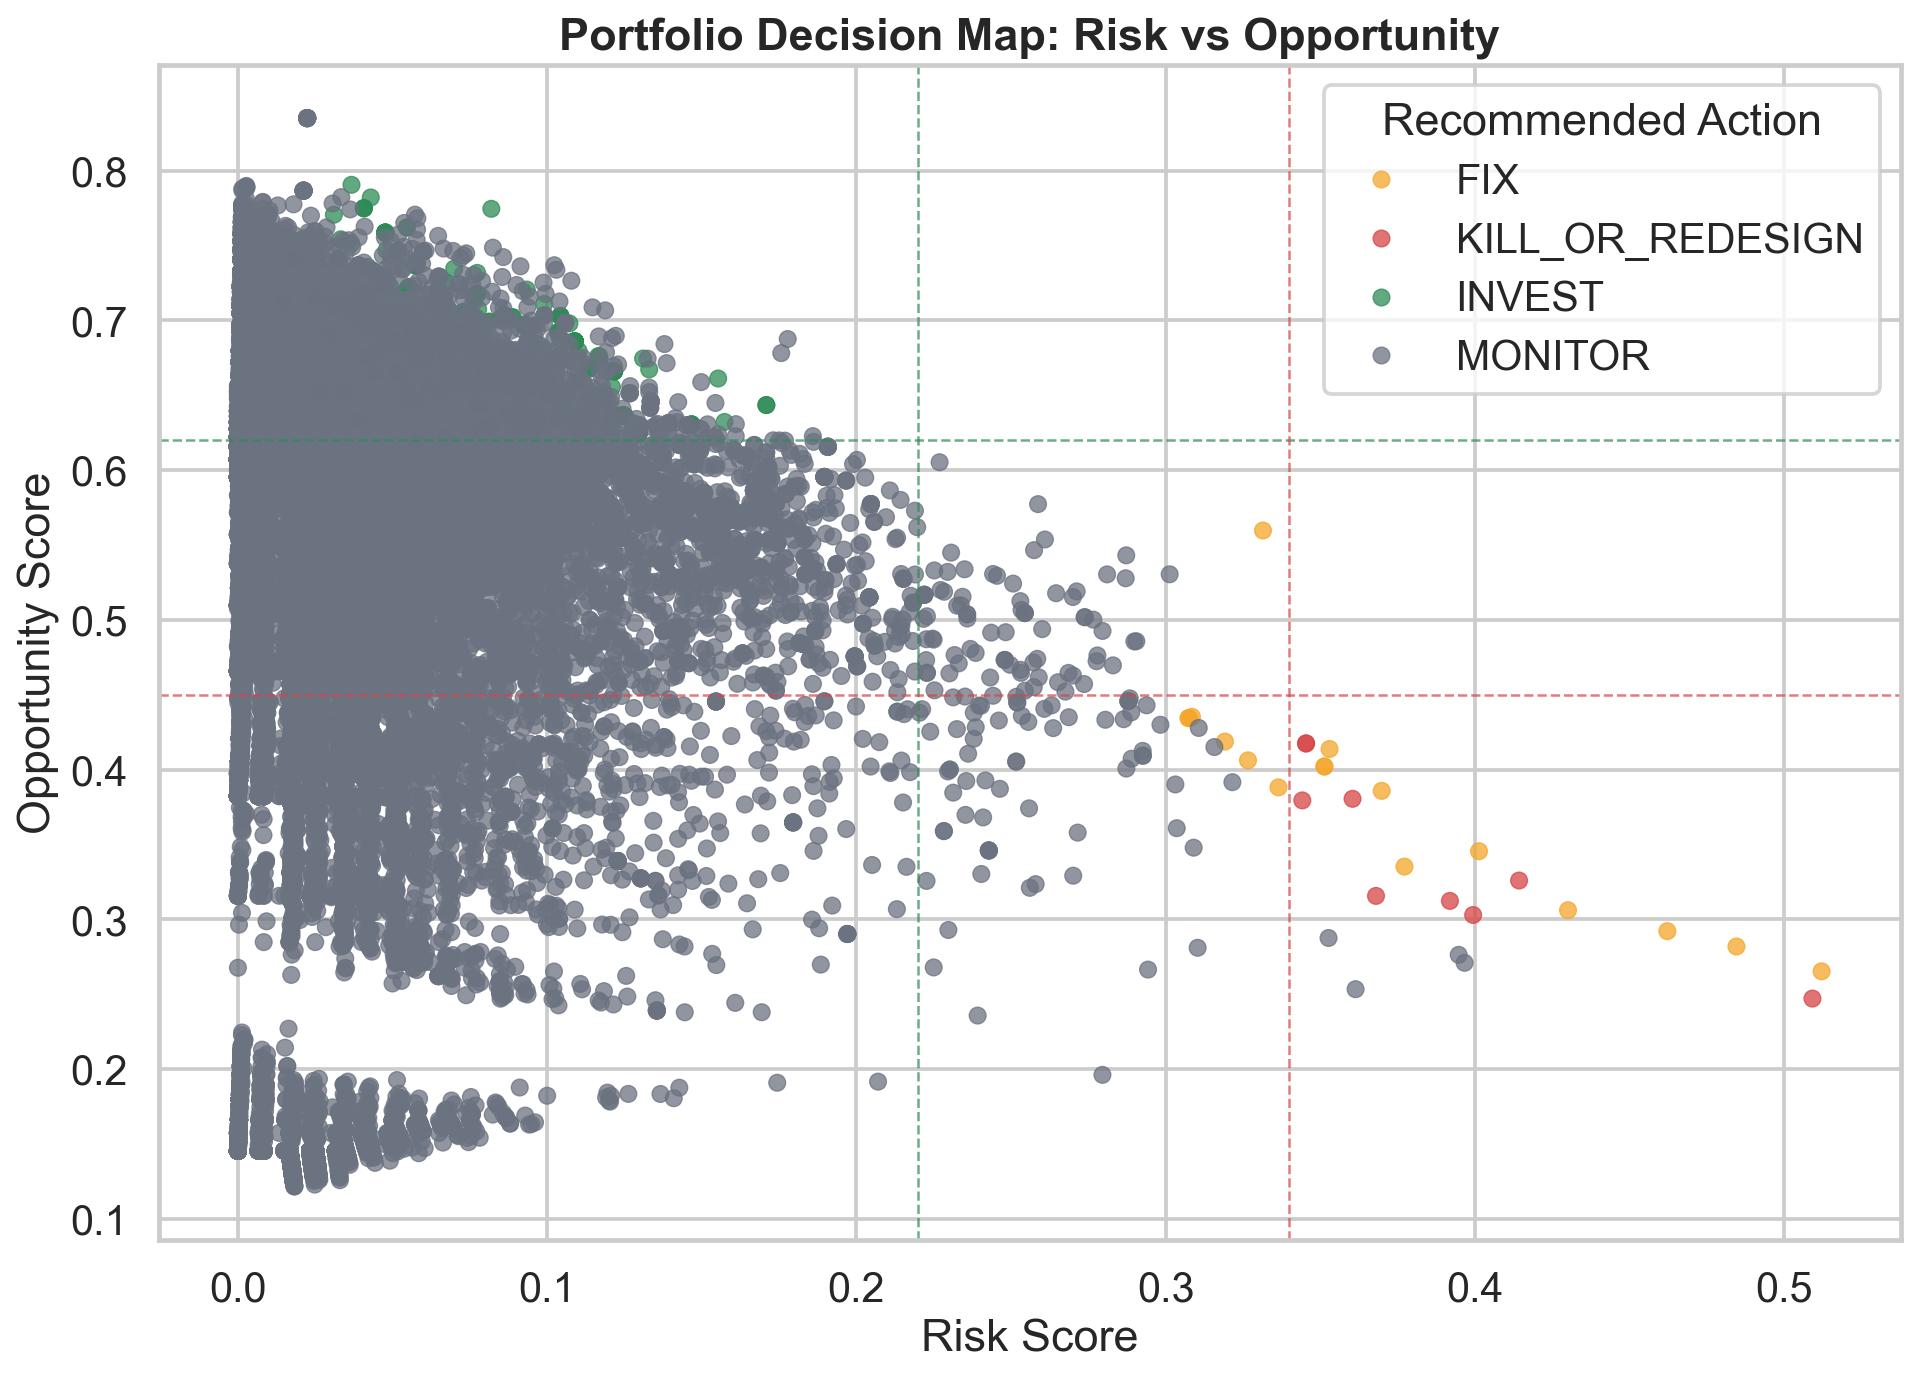

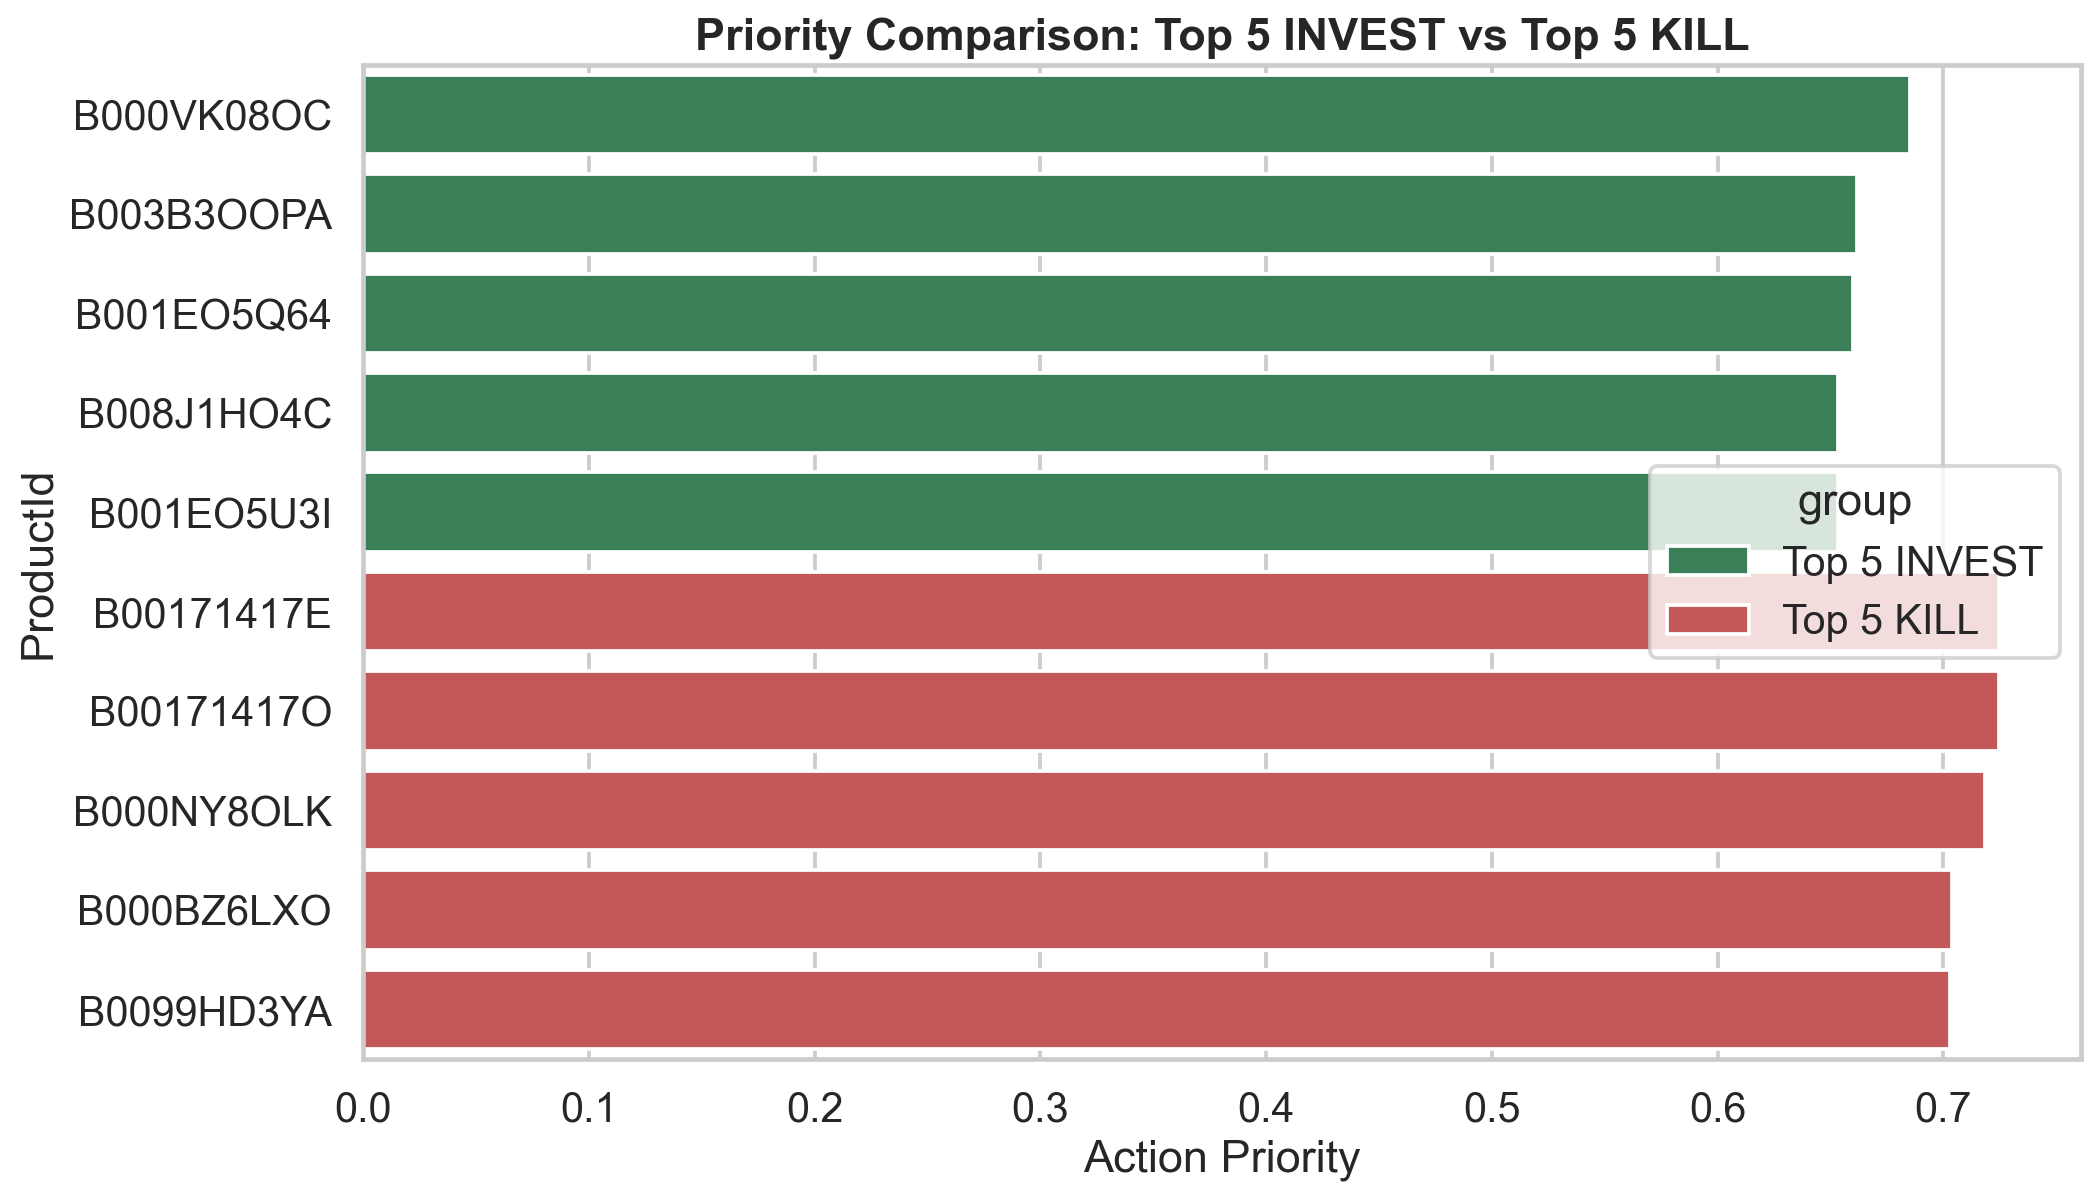

C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1766270944.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


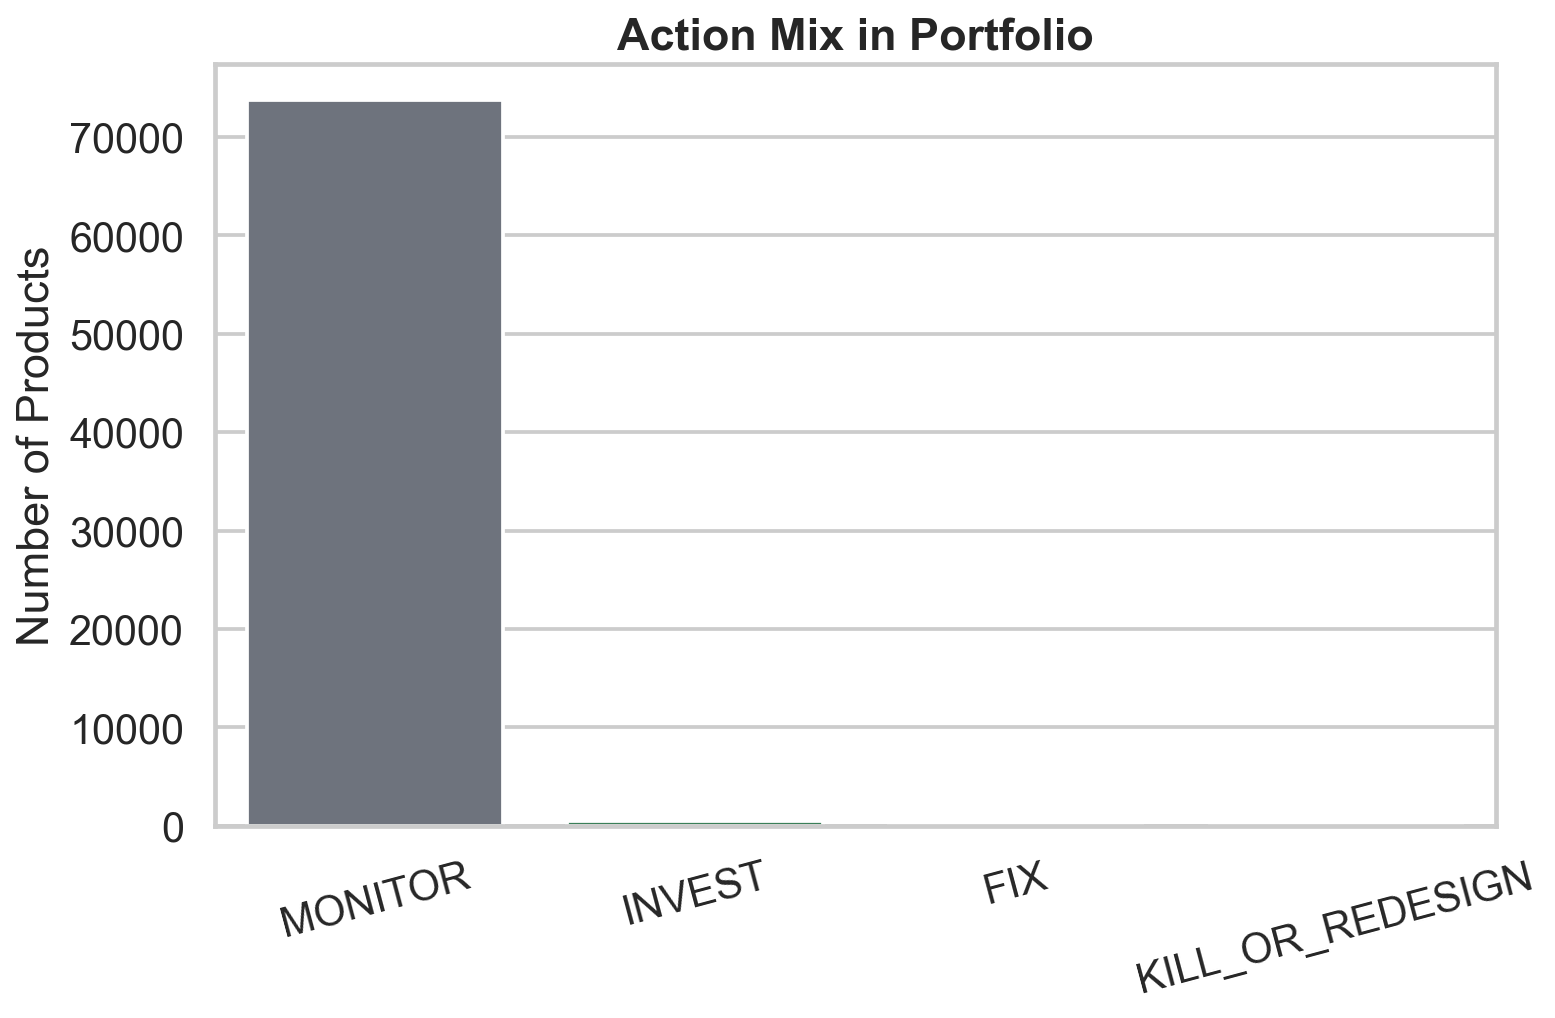

Export completed:
- strict_slide_charts/insight1_portfolio/01_risk_opportunity_map.png
- strict_slide_charts/insight1_portfolio/02_top5_priority_compare.png
- strict_slide_charts/insight1_portfolio/03_action_mix.png
- strict_slide_charts/insight1_portfolio/top5_invest.csv
- strict_slide_charts/insight1_portfolio/top5_kill.csv


,ProductId,review_count,mean_score,risk_score,opportunity_score,action_priority
23,B000VK08OC,232,4.491379,0.081944,0.774601,0.685236
26,B003B3OOPA,623,4.739968,0.036720,0.790643,0.661891
27,B001EO5Q64,567,4.746032,0.042959,0.782191,0.660120
28,B008J1HO4C,355,4.681690,0.054662,0.762178,0.653472
29,B001EO5U3I,355,4.681690,0.054662,0.762178,0.653472


,ProductId,review_count,mean_score,risk_score,opportunity_score,action_priority
15,B00171417E,32,2.718750,0.345425,0.417444,0.724726
16,B00171417O,32,2.718750,0.345425,0.417444,0.724726
18,B000NY8OLK,38,1.315789,0.509187,0.247019,0.718395
20,B000BZ6LXO,36,2.305556,0.360461,0.380462,0.703877
21,B0099HD3YA,34,2.117647,0.414313,0.325870,0.703173


In [46]:
# === INSIGHT 1 EXPORT PACK (Portfolio Optimization) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

OUT_DIR = "strict_slide_charts/insight1_portfolio"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) Safety check
if "decision_table" not in globals():
    # fallback if your variable is named decision_dashboard
    if "decision_dashboard" in globals():
        decision_table = decision_dashboard.copy()
    else:
        raise NameError("decision_table (or decision_dashboard) not found. Run decision-engine cells first.")

required_cols = [
    "ProductId", "review_count", "mean_score", "risk_score",
    "opportunity_score", "recommended_action"
]
missing = [c for c in required_cols if c not in decision_table.columns]
if missing:
    raise ValueError(f"Missing columns in decision_table: {missing}")

df = decision_table.copy()
if "action_priority" not in df.columns:
    # fallback priority if your table does not contain action_priority
    df["action_priority"] = 0.55 * df["opportunity_score"].fillna(0) + 0.45 * df["risk_score"].fillna(0)

# 2) Top 5 tables
top_invest_5 = (
    df[df["recommended_action"] == "INVEST"]
    .sort_values("action_priority", ascending=False)
    [["ProductId", "review_count", "mean_score", "risk_score", "opportunity_score", "action_priority"]]
    .head(5)
)

top_kill_5 = (
    df[df["recommended_action"] == "KILL_OR_REDESIGN"]
    .sort_values("action_priority", ascending=False)
    [["ProductId", "review_count", "mean_score", "risk_score", "opportunity_score", "action_priority"]]
    .head(5)
)

top_invest_5.to_csv(f"{OUT_DIR}/top5_invest.csv", index=False)
top_kill_5.to_csv(f"{OUT_DIR}/top5_kill.csv", index=False)

# 3) Figure A: Risk vs Opportunity map
plt.figure(figsize=(11, 8), dpi=180)
plot_df = df.copy()
plot_df["action_group"] = plot_df["recommended_action"].fillna("MONITOR")

palette = {
    "INVEST": "#2E8B57",
    "FIX": "#F4A62A",
    "KILL_OR_REDESIGN": "#D64545",
    "MONITOR": "#6B7280"
}

sns.scatterplot(
    data=plot_df,
    x="risk_score",
    y="opportunity_score",
    hue="action_group",
    palette=palette,
    alpha=0.75,
    s=45,
    edgecolor=None
)

# Optional reference lines (edit thresholds if needed)
plt.axvline(0.22, color="#2E8B57", linestyle="--", linewidth=1, alpha=0.7)
plt.axhline(0.62, color="#2E8B57", linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(0.34, color="#D64545", linestyle="--", linewidth=1, alpha=0.7)
plt.axhline(0.45, color="#D64545", linestyle="--", linewidth=1, alpha=0.7)

plt.title("Portfolio Decision Map: Risk vs Opportunity")
plt.xlabel("Risk Score")
plt.ylabel("Opportunity Score")
plt.legend(title="Recommended Action", loc="best", frameon=True)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_risk_opportunity_map.png", bbox_inches="tight")
plt.show()

# 4) Figure B: Top 5 Invest/Kill priority bars
bar_df = pd.concat([
    top_invest_5.assign(group="Top 5 INVEST"),
    top_kill_5.assign(group="Top 5 KILL")
], ignore_index=True)

if len(bar_df) > 0:
    plt.figure(figsize=(12, 7), dpi=180)
    sns.barplot(
        data=bar_df,
        y="ProductId",
        x="action_priority",
        hue="group",
        palette={"Top 5 INVEST": "#2E8B57", "Top 5 KILL": "#D64545"}
    )
    plt.title("Priority Comparison: Top 5 INVEST vs Top 5 KILL")
    plt.xlabel("Action Priority")
    plt.ylabel("ProductId")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/02_top5_priority_compare.png", bbox_inches="tight")
    plt.show()

# 5) Figure C: Action mix
action_mix = (
    df["recommended_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)
plt.figure(figsize=(9, 6), dpi=180)
sns.barplot(
    data=action_mix,
    x="action",
    y="count",
    palette=[palette.get(a, "#9CA3AF") for a in action_mix["action"]]
)
plt.title("Action Mix in Portfolio")
plt.xlabel("")
plt.ylabel("Number of Products")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_action_mix.png", bbox_inches="tight")
plt.show()

print("Export completed:")
print(f"- {OUT_DIR}/01_risk_opportunity_map.png")
print(f"- {OUT_DIR}/02_top5_priority_compare.png")
print(f"- {OUT_DIR}/03_action_mix.png")
print(f"- {OUT_DIR}/top5_invest.csv")
print(f"- {OUT_DIR}/top5_kill.csv")

display(top_invest_5)
display(top_kill_5)

## 15) Actionable Suggestions - Amazon Platform & Marketing

This section converts business insights into actionable analytics outputs.

**Structure:**
1. Shared data preparation for all insights
2. Amazon Insight #1: Prioritize helpful and detailed reviews
3. Amazon Insight #2: Product quality alert for 1-2 star spikes
4. Marketing Insight #1: Loyal customer segment (>50 reviews)
5. Marketing Insight #2: 5-star keyword optimization for SEO/Google Ads
6. Marketing Insight #3: Media-risk monitoring from score trends

In [50]:
# ======================================================
# SETUP CHUNG CHO CÁC INSIGHT
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

print("[COMMENT] Initialize shared standardized fields for all insights.")

if 'df' not in globals():
    raise ValueError("Không tìm thấy DataFrame df. Hãy chạy các cell load/clean trước.")

# Try to auto-detect a review-level dataframe (df can be overwritten later by decision tables)
required_review_cols = {'ProductId', 'Score'}
text_candidates = {'Text', 'text_clean'}
time_candidates = {'Time', 'time', 'unixReviewTime', 'review_datetime'}

selected_name, selected_df = None, None

# Priority order for known variables in this notebook
for name in ['df', 'ndf']:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        cset = set(globals()[name].columns)
        if required_review_cols.issubset(cset) and (len(text_candidates & cset) > 0):
            selected_name, selected_df = name, globals()[name]
            break

# Fallback: scan all dataframe variables in globals
if selected_df is None:
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            cset = set(obj.columns)
            if required_review_cols.issubset(cset) and (len(text_candidates & cset) > 0):
                selected_name, selected_df = name, obj
                break

if selected_df is None:
    raise ValueError(
        "No review-level DataFrame found for insights. "
        "Please rerun preprocessing cells (cleaning + sentiment/text_clean), "
        "or ensure df/ndf still contains ProductId, Score, and Text (or text_clean)."
    )

insight_df = selected_df.copy()
print(f"[COMMENT] Insight source dataframe: {selected_name}")

# Robust time-column detection to avoid KeyError when schema changes
time_col = next((c for c in ['Time', 'time', 'unixReviewTime', 'review_datetime'] if c in insight_df.columns), None)

if time_col is None:
    # Some aggregated tables only keep last_review_date; fallback to it so cells can still run
    if 'last_review_date' in insight_df.columns:
        insight_df['review_datetime'] = pd.to_datetime(insight_df['last_review_date'], errors='coerce')
        print("[COMMENT] Standard time column not found; using fallback last_review_date.")
    else:
        raise ValueError(
            "No time column found in the insight source DataFrame. "
            f"Columns hiện có: {insight_df.columns.tolist()}"
        )
else:
    if str(insight_df[time_col].dtype).startswith('datetime'):
        insight_df['review_datetime'] = pd.to_datetime(insight_df[time_col], errors='coerce')
    else:
        insight_df['review_datetime'] = pd.to_datetime(insight_df[time_col], unit='s', errors='coerce')

insight_df['review_month'] = insight_df['review_datetime'].dt.to_period('M').astype(str)

# Biến tiện ích
insight_df['text_len'] = insight_df['Text'].fillna('').astype(str).str.len()
insight_df['summary_len'] = insight_df['Summary'].fillna('').astype(str).str.len()
insight_df['detail_len'] = insight_df['text_len'] + insight_df['summary_len']

insight_df['helpful_num'] = pd.to_numeric(insight_df['HelpfulnessNumerator'], errors='coerce').fillna(0)
insight_df['helpful_den'] = pd.to_numeric(insight_df['HelpfulnessDenominator'], errors='coerce').fillna(0)
insight_df['helpful_ratio'] = np.where(insight_df['helpful_den'] > 0,
                                       insight_df['helpful_num'] / insight_df['helpful_den'],
                                       0.0)

print(f"[COMMENT] Reviews available for insight analysis: {len(insight_df):,}")

[COMMENT] Khởi tạo các cột chuẩn để mọi insight dùng chung, giúp code ổn định và dễ kiểm soát.
[COMMENT] Insight source dataframe: ndf
[COMMENT] Số review sẵn sàng phân tích: 567,109


### Insight A1 - Amazon Platform: Prioritize Helpful and Detailed Reviews

**Goal:** Validate whether highly helpful reviews are typically more detailed (longer text).  
**Action:** If true, rank high-utility reviews at the top of the product page.

[INSIGHT A1] Phân tích mối liên hệ giữa độ chi tiết review và tính hữu ích.
[COMMENT] Tương quan helpful_ratio vs detail_len: 0.1246
[COMMENT] Tương quan utility_score vs detail_len: 0.1797
[OUTPUT] Nhóm Q4 (utility cao) là nhóm nên được ưu tiên hiển thị trên đầu trang.


,utility_group,review_count,avg_detail_len,avg_helpful_ratio,avg_score
0,Q1 thấp,141778,194.934941,0.000000,4.515369
1,Q2,141777,538.010855,0.000000,4.202628
2,Q3,141777,462.544538,0.636911,3.644745
3,Q4 cao,141777,633.876327,0.994240,4.373199


C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\390974611.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=a1_table, x='utility_group', y='avg_detail_len', palette='Blues')


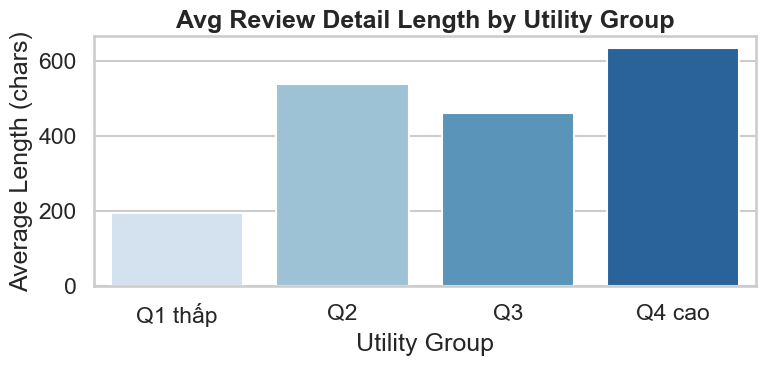

In [51]:
# ------------------------------------------------------
# INSIGHT A1: Review Utility Score for display ranking
# ------------------------------------------------------
print("[INSIGHT A1] Analyze the relationship between review detail and helpfulness.")

insight_df['help_log'] = np.log1p(insight_df['helpful_den'])
insight_df['detail_log'] = np.log1p(insight_df['detail_len'])

help_norm = insight_df['help_log'] / (insight_df['help_log'].max() if insight_df['help_log'].max() > 0 else 1)
detail_norm = insight_df['detail_log'] / (insight_df['detail_log'].max() if insight_df['detail_log'].max() > 0 else 1)

# Trọng số có thể tinh chỉnh theo business objective
insight_df['review_utility_score'] = 0.55 * insight_df['helpful_ratio'] + 0.25 * help_norm + 0.20 * detail_norm

corr_help_detail = insight_df[['helpful_ratio', 'detail_len']].corr().iloc[0, 1]
corr_utility_detail = insight_df[['review_utility_score', 'detail_len']].corr().iloc[0, 1]

print(f"[COMMENT] Correlation helpful_ratio vs detail_len: {corr_help_detail:.4f}")
print(f"[COMMENT] Correlation utility_score vs detail_len: {corr_utility_detail:.4f}")

insight_df['utility_group'] = pd.qcut(insight_df['review_utility_score'].rank(method='first'), 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])

a1_table = insight_df.groupby('utility_group', observed=False).agg(
    review_count=('Score', 'size'),
    avg_detail_len=('detail_len', 'mean'),
    avg_helpful_ratio=('helpful_ratio', 'mean'),
    avg_score=('Score', 'mean')
).reset_index()

print("[OUTPUT] Q4 high-utility reviews are the top candidates for priority display.")
display(a1_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=a1_table, x='utility_group', y='avg_detail_len', palette='Blues')
plt.title('Avg Review Detail Length by Utility Group')
plt.xlabel('Utility Group')
plt.ylabel('Average Length (chars)')
plt.tight_layout()
plt.show()

### Insight A2 - Amazon Platform: Product Quality Early Warning

**Goal:** Detect products with abnormal 1-2 star review spikes in a short time window.  
**Action:** Trigger quality alerts for supply/logistics checks; if persistent, consider delisting.

In [52]:
# ------------------------------------------------------
# INSIGHT A2: Early warning for 1-2 star spikes
# ------------------------------------------------------
print("[INSIGHT A2] Detect products with high 1-2 star rates by month.")

tmp = insight_df.dropna(subset=['review_datetime']).copy()
tmp['is_low_star'] = tmp['Score'].isin([1, 2]).astype(int)

a2_monthly = tmp.groupby(['ProductId', 'review_month']).agg(
    total_reviews=('Score', 'size'),
    low_star_reviews=('is_low_star', 'sum')
).reset_index()
a2_monthly['low_star_rate'] = a2_monthly['low_star_reviews'] / a2_monthly['total_reviews']

# Alert rule: at least 10 reviews/month and low-star-rate >= 50%
a2_alert = a2_monthly[(a2_monthly['total_reviews'] >= 10) & (a2_monthly['low_star_rate'] >= 0.5)].copy()
a2_alert = a2_alert.sort_values(['low_star_rate', 'low_star_reviews'], ascending=False)

print("[OUTPUT] Product quality warning months (top 20):")
display(a2_alert.head(20))

a2_risk_products = a2_alert.groupby('ProductId').size().reset_index(name='warning_months')
a2_risk_products = a2_risk_products.sort_values('warning_months', ascending=False)

print("[COMMENT] Products with >=2 warning months should be prioritized for quality audit.")
print("[OUTPUT] Top high-risk products:")
display(a2_risk_products.head(20))

# Chart for Insight A2
if len(a2_risk_products) > 0:
    top_risk = a2_risk_products.head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_risk, x='warning_months', y='ProductId', palette='Reds_r')
    plt.title('Top 10 Products by Number of Warning Months')
    plt.xlabel('Warning Months')
    plt.ylabel('ProductId')
    plt.tight_layout()
    plt.show()

[INSIGHT A2] Phát hiện sản phẩm có tỷ lệ review 1-2 sao cao theo tháng.
[OUTPUT] Danh sách tháng cảnh báo chất lượng sản phẩm (top 20):


,ProductId,review_month,total_reviews,low_star_reviews,low_star_rate
319419,B006N3I69A,2011-02,22,22,1.000000
319420,B006N3I69A,2011-03,12,12,1.000000
124607,B000X1Q1G8,2012-07,10,10,1.000000
287812,B004H3N2LU,2011-01,18,17,0.944444
195466,B001M08YZA,2012-09,16,15,0.937500
319418,B006N3I69A,2011-01,31,29,0.935484
294164,B004OAZ36I,2012-10,14,13,0.928571
327686,B0083T5TAQ,2012-10,14,13,0.928571
1225,B000084ETV,2008-08,12,11,0.916667
29070,B0009XQWDM,2008-08,12,11,0.916667


[COMMENT] Sản phẩm có >=2 tháng cảnh báo nên được ưu tiên audit chất lượng.
[OUTPUT] Top sản phẩm rủi ro:


,ProductId,warning_months
72,B0085MLY5A,4
62,B005BHIESC,4
68,B006N3I69A,3
14,B000X1Q1G8,3
54,B004JRXZKM,3
56,B004Q3LBTG,3
11,B000KV7ZGQ,3
10,B000KV61FC,3
8,B000F6SNPS,2
50,B004342XH2,2


### Insight M1 - Marketing: Loyal Customer Segment (>50 reviews)

**Goal:** Identify highly active users for voucher campaigns and expert-review programs.

> Business example: expected around 260 users depending on data scope and cleaning pipeline.

In [53]:
# ------------------------------------------------------
# INSIGHT M1: Loyal customers (>50 reviews)
# ------------------------------------------------------
print("[INSIGHT M1] Identify loyal users based on UserId activity.")

m1_users = insight_df.groupby('UserId').size().reset_index(name='review_count')
m1_loyal = m1_users[m1_users['review_count'] > 50].sort_values('review_count', ascending=False)

print(f"[OUTPUT] Number of loyal users (>50 reviews): {len(m1_loyal)}")
print("[COMMENT] Compare this result with your target baseline (e.g., around 260 users).")
display(m1_loyal.head(30))

# Chart for Insight M1
if len(m1_loyal) > 0:
    top_loyal = m1_loyal.head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_loyal, x='review_count', y='UserId', palette='Purples_r')
    plt.title('Top 15 Loyal Users by Review Count')
    plt.xlabel('Review Count')
    plt.ylabel('UserId')
    plt.tight_layout()
    plt.show()

[INSIGHT M1] Xác định nhóm người dùng trung thành dựa trên UserId.
[OUTPUT] Số lượng user trung thành (>50 review): 251
[COMMENT] So sánh con số này với mốc kỳ vọng (ví dụ 260 users) để hiệu chỉnh chiến dịch.


,UserId,review_count
182000,A3OXHLG6DIBRW8,442
65582,A1YUL9PCJR3JTY,410
252260,AY12DBB0U420B,389
82913,A281NPSIMI1C2R,365
66157,A1Z54EM24Y40LL,256
110857,A2MUGFV2TDQ47K,201
238439,AQQLWCMRNDFGI,176
122365,A2SZLNSI5KOQJT,175
255791,AZV26LP92E6WU,167
138632,A31N6KB160O508,162


### Insight M2 - Marketing: Ad Keyword Optimization from 5-Star Reviews

**Goal:** Use real customer language to improve CTR, improve Quality Score, and lower CPC.

- Extract the most frequent positive terms
- Visualize top keywords
- Generate practical SEO + Google Ads suggestions (headline/callout)

[INSIGHT M2] Trích xuất từ khóa tích cực từ nhóm 5 sao để phục vụ SEO/Google Ads.
[OUTPUT] Top keywords tích cực từ review 5 sao:


,keyword,frequency
0,them,141919
1,love,122180
2,coffee,108398
3,tea,105342
4,taste,98067
5,best,90920
6,flavor,89842
7,when,83419
8,it's,82997
9,will,78530


C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\1859717790.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=m2_top.head(15), x='frequency', y='keyword', palette='Greens_r')


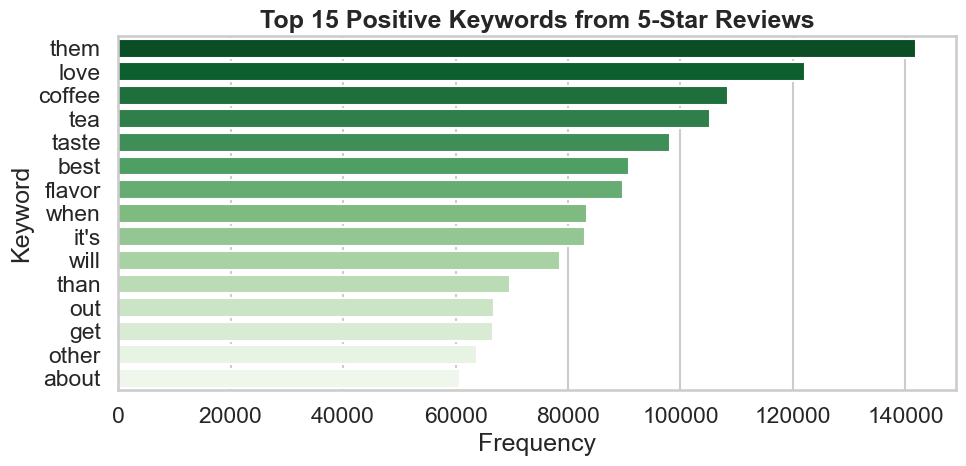

[COMMENT] Gợi ý ứng dụng thực tế:
- SEO description terms: them, love, coffee, tea, taste
- Google Ads headline mẫu: 'Dark Chocolate with them & love texture'
- Callout extension mẫu: 'coffee taste | customer-loved quality'


,keyword,frequency
0,them,141919
1,love,122180
2,coffee,108398
3,tea,105342
4,taste,98067
5,best,90920
6,flavor,89842
7,when,83419
8,it's,82997
9,will,78530


C:\Users\hatca\AppData\Local\Temp\ipykernel_11832\566937707.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=m2_top.head(15), x='frequency', y='keyword', palette='Greens_r')


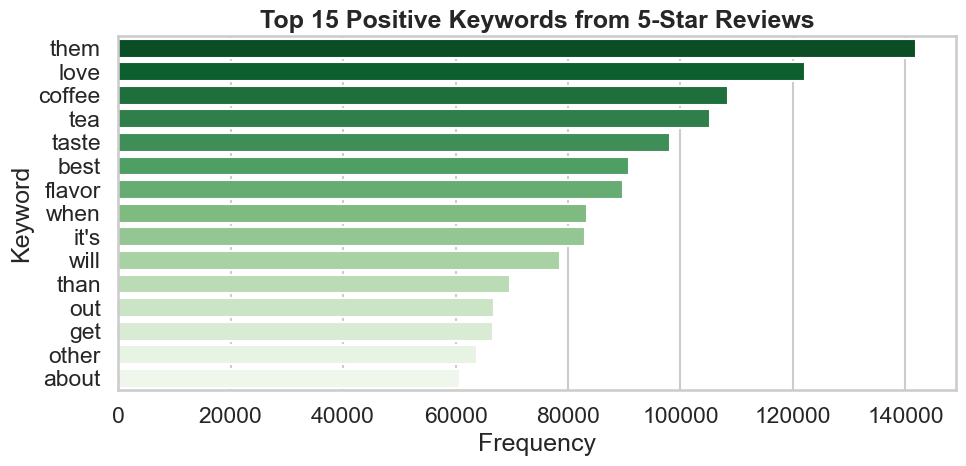

[COMMENT] Practical activation ideas:
- SEO description terms: them, love, coffee, tea, taste
- Google Ads headline mẫu: 'Dark Chocolate with them & love texture'
- Callout extension mẫu: 'coffee taste | customer-loved quality'


In [61]:
# ------------------------------------------------------
# INSIGHT M2: Positive keywords from 5-star reviews
# ------------------------------------------------------
print("[INSIGHT M2] Extract positive keywords from 5-star reviews for SEO/Google Ads.")

m2_5star = insight_df[insight_df['Score'] == 5].copy()
m2_text = (m2_5star['Summary'].fillna('') + ' ' + m2_5star['Text'].fillna('')).str.lower()

# Stopwords cơ bản, có loại từ chung chung như good/great để ưu tiên từ đặc trưng hơn
stopwords = {
    'the','a','an','and','or','for','to','of','in','on','at','is','it','this','that','these','those',
    'i','we','you','they','he','she','my','our','your','their','be','been','am','are','was','were',
    'very','really','just','with','as','from','by','if','but','so','too','can','could','would','should',
    'have','has','had','do','does','did','not','no','yes','all','more','most','much','many','some','any',
    'product','amazon','food','buy','bought','purchase','one','two','three','also','like','good','great'
}

tokens = []
for doc in m2_text:
    words = re.findall(r"[a-zA-Z][a-zA-Z\-']+", doc)
    words = [w for w in words if (w not in stopwords and len(w) > 2)]
    tokens.extend(words)

m2_freq = Counter(tokens)
m2_top = pd.DataFrame(m2_freq.most_common(25), columns=['keyword', 'frequency'])

print("[OUTPUT] Top positive keywords from 5-star reviews:")
display(m2_top)

plt.figure(figsize=(10, 5))
sns.barplot(data=m2_top.head(15), x='frequency', y='keyword', palette='Greens_r')
plt.title('Top 15 Positive Keywords from 5-Star Reviews')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

top_words = m2_top['keyword'].head(6).tolist()
print("[COMMENT] Practical activation ideas:")
if len(top_words) >= 3:
    print(f"- SEO description terms: {', '.join(top_words[:5])}")
    print(f"- Google Ads headline mẫu: 'Dark Chocolate with {top_words[0]} & {top_words[1]} texture'")
    print(f"- Callout extension mẫu: '{top_words[2]} taste | customer-loved quality'")
else:
    print("- Chưa đủ keyword nổi bật, cân nhắc nới điều kiện lọc từ/token.")

### Insight M3 - Marketing: Media Risk Monitoring from Score Trends

**Goal:** If average scores decline over time, trigger coordinated customer-care responses on low-score reviews.

**Suggested automation:**
- Alert when trend slope < 0
- Prioritize the most recent 1-2 star reviews for response

[INSIGHT M3] Theo dõi xu hướng điểm trung bình để phát hiện tín hiệu khủng hoảng sớm.
[OUTPUT] Slope xu hướng điểm trung bình theo tháng: -0.001927
[COMMENT] Xu hướng GIẢM: kích hoạt playbook CSKH phản hồi review 1-2 sao để giảm khủng hoảng truyền thông.


,review_month,avg_score,review_count
131,2011-11,4.133625,16217
132,2011-12,4.080273,19035
133,2012-01,4.095794,21682
134,2012-02,4.105300,18794
135,2012-03,4.071548,19707
136,2012-04,4.126581,18897
137,2012-05,4.119509,19396
138,2012-06,4.085024,18089
139,2012-07,4.147719,19835
140,2012-08,4.124053,19798


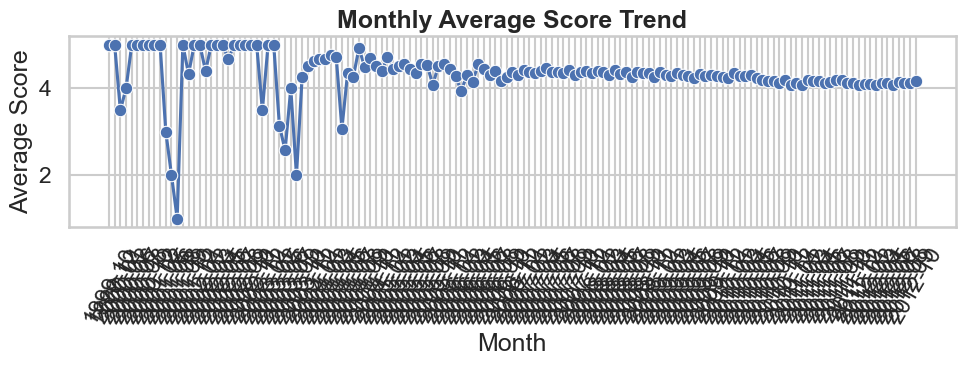

[OUTPUT] Top review 1-2 sao gần nhất (đề xuất CSKH phản hồi trước):


,Id,ProductId,UserId,Score,review_datetime,Summary,Text
362190,362191,B0005YW0TU,A22SW4MALCSDWV,1,2012-10-26,Inedible,I am one of the least picky eaters that I know...
376403,376404,B0099AUJBW,A36L1OMFLJ1ZX6,2,2012-10-26,How did u make it??!!!,I have seen lots of reviews about how bitter t...
464364,464365,B000UBD88A,AWRFQYLG7LQKJ,2,2012-10-26,Not very strong,Not as strong as the regular dark coffee. Dis...
164779,164780,B0029NVPLE,A3RKYD8IUC5S0N,2,2012-10-26,Messy and apparently undelicious,"My cat is not a huge fan. Sure, she'll lap up ..."
93365,93366,B007TGDXMU,AGUBQN9M09VQ4,1,2012-10-26,Not what I expected,"First of all the ""k-cups"" were weird and the t..."
173934,173935,B005HUVI40,A1DV7TLJ1HT08H,1,2012-10-26,"great product, poor delivery",The coffee is excellent and I am a repeat buye...
24517,24518,B0016JJEFG,AO9WE22147CRH,1,2012-10-26,bad tasting tea,We drink a lot of tea... from all over the wor...
440485,440486,B002ZOCEMG,A1LIP0F4R542OQ,1,2012-10-26,:(,I just got this coffee a few days ago. I had c...
325314,325315,B0033GMSTY,A1DV7TLJ1HT08H,1,2012-10-26,"great product, poor delivery",The coffee is excellent and I am a repeat buye...
544205,544206,B003P9XFTG,A1X4OJBDP7HMTZ,2,2012-10-26,Blue Buffalo Wilderness,Very disappointed with this product. I've read...


In [55]:
# ------------------------------------------------------
# INSIGHT M3: Score trend for early media-risk warning
# ------------------------------------------------------
print("[INSIGHT M3] Monitor average score trends to detect early media-risk signals.")

m3 = insight_df.dropna(subset=['review_datetime']).copy()
m3_month = m3.groupby('review_month').agg(
    avg_score=('Score', 'mean'),
    review_count=('Score', 'size')
).reset_index()

x = np.arange(len(m3_month))
y = m3_month['avg_score'].values
slope = np.polyfit(x, y, 1)[0] if len(m3_month) > 1 else 0.0

print(f"[OUTPUT] Monthly average-score trend slope: {slope:.6f}")
if slope < 0:
    print("[COMMENT] Downward trend detected: activate customer-care response playbook for 1-2 star reviews.")
else:
    print("[COMMENT] Stable/upward trend: continue periodic monitoring.")

display(m3_month.tail(12))

plt.figure(figsize=(10, 4))
sns.lineplot(data=m3_month, x='review_month', y='avg_score', marker='o')
plt.xticks(rotation=60)
plt.title('Monthly Average Score Trend')
plt.xlabel('Month')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

# Danh sách review thấp điểm gần nhất để CSKH ưu tiên phản hồi
recent_low = m3[m3['Score'].isin([1, 2])].sort_values('review_datetime', ascending=False)
print("[OUTPUT] Most recent 1-2 star reviews (prioritize for customer-care response):")
display(recent_low[['Id', 'ProductId', 'UserId', 'Score', 'review_datetime', 'Summary', 'Text']].head(20))